In [8]:
# ============================================================
# Cell 0 — Parameters
# ============================================================
"""
Parameters from Table I of:
Gioannini & Rossetti, "Time-Domain Traveling Wave Model of Quantum Dot DFB Lasers"
IEEE J. Sel. Top. Quantum Electron., Vol. 17, No. 5, 2011

All values are in SI units unless noted.
"""

import numpy as np
import os

# ── Physical constants ────────────────────────────────────────────────────────
q        = 1.602176634e-19   # elementary charge (C)
hbar     = 1.054571817e-34   # reduced Planck constant (J·s)
kB       = 1.380649e-23      # Boltzmann constant (J/K)
c0       = 2.997924580e8     # speed of light in vacuum (m/s)
eps0     = 8.854187817e-12   # vacuum permittivity (F/m)
m0       = 9.1093837015e-31  # free electron mass (kg)
T        = 300.0             # room temperature (K)
tau_e_e_W   = 2.869769446792076e-12
tau_e_h_qd  = 4.695960593559146e-10
tau_e_e_ES1 = 7.290147443730576e-12
tau_e_e_ES2 = 5.910580830906274e-11
tau_e_e_GS  = 1.5507328851608195e-11

# ── Material parameters ───────────────────────────────────────────────────────
h_w      = 5e-9              # QD layer height (m)
eta      = 3.3445            # effective refractive index (dimensionless)
N_l      = 8                 # number of QD layers
N_D      = 5.9e14            # QD surface density (m⁻²)  [5.9×10¹⁰ cm⁻² → ×10⁴]
N_groups = 51                # number of QD groups for inhomogeneous broadening

# State degeneracies: D_m for m = ES2, ES1, GS
D = {
    'ES2': 6,
    'ES1': 4,
    'GS':  2,
}

hbar_Gamma = 7e-3 * q       # homogeneous linewidth (J)  [7 meV → ×q]
Gamma      = hbar_Gamma / hbar  # dephasing rate (rad/s)

Delta_E    = 38e-3 * q      # FWHM of inhomogeneous broadening (J)  [38 meV]

# Dipole matrix elements A_m  (cm³·eV → m³·J)
# 1 cm³·eV = 1e-6 m³ × 1.602e-19 J  →  multiply by 1e-6 * q
A = {
    'ES1': 1.26e-20 * 1e-6 * q,   # m³·J
    'GS':  2.03e-20 * 1e-6 * q,   # m³·J
}

# SCH diffusion/transport times (s)
tau_c_e_W  = 1.2e-12        # electron transport time across SCH (s)
tau_c_h_W  = 23.2e-12       # hole transport time across SCH (s)

tau_e_e_W  = 0.0492e-12

# Electron relaxation times τ_c^{e,m} for m = ES2, ES1, GS (s)
tau_c_e = {
    'ES2': 3e-12,
    'ES1': 2e-12,
    'GS':  2e-12,
}

tau_e_e_im = {
    'ES2': 6.15e-12,
    'ES1': 7.99e-12,
    'GS':  10.63e-12,
}

# Interband recombination time in the WL (s)
tau_r_e_W  = 100e-12

tau_e_h_qd = 1.46E-12

# Spontaneous emission recombination times τ_Sp^m for m = ES2, ES1, GS (s)
tau_Sp = {
    'ES2': 2.8e-9,
    'ES1': 2.8e-9,
    'GS':  2.8e-9,
}

# Auger recombination times τ_Au^m for m = ES2, ES1, GS (s)
tau_Au = {
    'ES2': 110e-12,
    'ES1': 275e-12,
    'GS':  660e-12,
}

# Interband transition energies hbar*omega_im for i=(N+1)/2 (central group)
# m = ES2, ES1, GS  (eV → J)
hbar_omega = {
    'ES2': 1.098 * q,   # J
    'ES1': 1.042 * q,
    'GS':  0.959 * q,   # J
}

# Reference (Bragg) angular frequency — set to GS transition of central group
omega_0 = hbar_omega['GS'] / hbar   # rad/s

# Intrinsic waveguide losses (m⁻¹)  [1.5 cm⁻¹ → ×100]
alpha_i  = 1.5e2

# ── Device parameters ─────────────────────────────────────────────────────────
W        = 2.2e-6            # ridge equivalent width (m)
h_SCH    = 430e-9            # SCH height (m)
r0_sq    = 0.90              # power reflectivity at z=0  (HR facet)
rL_sq    = 0.00              # power reflectivity at z=L  (AR facet)
L        = 400e-6            # total cavity length (m)
k_DFB    = 40e2              # grating coupling coefficient (m⁻¹)  [40 cm⁻¹]

# ── Derived / assumed parameters ──────────────────────────────────────────────
# Internal quantum efficiency (50% per [7] in the paper)
eta_i    = 0.50

# Field confinement factor in QD layers (lateral × transverse)
# Not given in table; typical value for this ridge geometry
Gamma_xy = 0.03             # (dimensionless) — approximate; tune to match gain

# Optical confinement factor of the SCH
Gamma_xy_SCH = 0.3          # (dimensionless) — approximate

# ── QD group energies (Gaussian inhomogeneous distribution) ──────────────────
# Groups indexed i = 0 ... N_groups-1; central group i_c = (N_groups-1)//2
sigma    = Delta_E / (2 * np.sqrt(2 * np.log(2)))   # Gaussian sigma (J)
i_c      = (N_groups - 1) // 2                       # index of central group
i_arr    = np.arange(N_groups)                        # 0 … 50

# Energy offset of each group from central group (evenly spaced, ±3σ span)
# Total span set to 4×FWHM to capture >99% of distribution
E_span   = 4 * Delta_E                               # total span (J)
dE       = E_span / (N_groups - 1)                   # spacing between groups

# GS transition energy for each group
E_GS_i   = hbar_omega['GS'] + (i_arr - i_c) * dE    # (J), shape (N_groups,)

# ES1 and ES2 energies follow same offset as GS (rigid shift of whole spectrum)
E_ES1_i  = hbar_omega['ES1'] + (i_arr - i_c) * dE
E_ES2_i  = hbar_omega['ES2'] + (i_arr - i_c) * dE

# Gaussian weighting G_i (normalised so sum = 1)
G_i      = np.exp(-0.5 * ((i_arr - i_c) * dE / sigma) ** 2)
G_i     /= G_i.sum()

# ── Valence-band confined-state energies (hole states) ───────────────────────
# Five hole confined states (GS, ES1…ES4) equally separated by 12 meV
# (stated in Section III-A of the paper)
delta_h  = 12e-3 * q        # hole level separation (J)
# Hole state energies relative to WL (negative = below WL continuum)
# Labelled GS=0, ES1=1, ES2=2, ES3=3, ES4=4
n_hole_states = 5
E_hole   = np.array([-k * delta_h for k in range(n_hole_states)])  # (J)
D_hole   = np.array([2, 4, 6, 8, 10])  # degeneracy (assumed 2*(k+1))

# ── Collect everything into a single dictionary ───────────────────────────────
params = {
    # Physical constants
    'q':            q,
    'hbar':         hbar,
    'kB':           kB,
    'c0':           c0,
    'eps0':         eps0,
    'm0':           m0,
    'T':            T,

    # Material
    'h_w':          h_w,
    'eta':          eta,
    'N_l':          N_l,
    'N_D':          N_D,
    'N_groups':     N_groups,
    'D':            D,
    'hbar_Gamma':   hbar_Gamma,
    'Gamma':        Gamma,
    'Delta_E':      Delta_E,
    'A':            A,
    'tau_c_e_W':    tau_c_e_W,
    'tau_e_e_W':    tau_e_e_W,
    'tau_c_h_W':    tau_c_h_W,
    'tau_e_h_qd':   tau_e_h_qd,
    'tau_c_e':      tau_c_e,
    'tau_e_e_im':   tau_e_e_im,
    'tau_r_e_W':    tau_r_e_W,
    'tau_Sp':       tau_Sp,
    'tau_Au':       tau_Au,
    'hbar_omega':   hbar_omega,
    'omega_0':      omega_0,
    'alpha_i':      alpha_i,

    # Device
    'W':            W,
    'h_SCH':        h_SCH,
    'r0_sq':        r0_sq,
    'rL_sq':        rL_sq,
    'L':            L,
    'k_DFB':        k_DFB,

    # Derived / assumed
    'eta_i':        eta_i,

    'Gamma_xy':     Gamma_xy,
    'Gamma_xy_SCH': Gamma_xy_SCH,

    # QD group arrays (length N_groups)
    'i_arr':        i_arr,
    'G_i':          G_i,
    'E_GS_i':       E_GS_i,
    'E_ES1_i':      E_ES1_i,
    'E_ES2_i':      E_ES2_i,
    'dE':           dE,

    # Hole confined states
    'n_hole_states': n_hole_states,
    'E_hole':       E_hole,
    'D_hole':       D_hole,
    'delta_h':      delta_h,
}


if __name__ == '__main__':
    print("=== QD-DFB Laser Parameters (SI units) ===\n")
    for k, v in params.items():
        if isinstance(v, np.ndarray):
            print(f"  {k:20s}: array shape {v.shape}, "
                  f"range [{v.min():.4g}, {v.max():.4g}]")
        elif isinstance(v, dict):
            print(f"  {k:20s}: {v}")
        else:
            print(f"  {k:20s}: {v:.6g}" if isinstance(v, float) else
                  f"  {k:20s}: {v}")

=== QD-DFB Laser Parameters (SI units) ===

  q                   : 1.60218e-19
  hbar                : 1.05457e-34
  kB                  : 1.38065e-23
  c0                  : 2.99792e+08
  eps0                : 8.85419e-12
  m0                  : 9.10938e-31
  T                   : 300
  h_w                 : 5e-09
  eta                 : 3.3445
  N_l                 : 8
  N_D                 : 5.9e+14
  N_groups            : 51
  D                   : {'ES2': 6, 'ES1': 4, 'GS': 2}
  hbar_Gamma          : 1.12152e-21
  Gamma               : 1.06349e+13
  Delta_E             : 6.08827e-21
  A                   : {'ES1': 2.0187425588399996e-45, 'GS': 3.25241856702e-45}
  tau_c_e_W           : 1.2e-12
  tau_e_e_W           : 4.92e-14
  tau_c_h_W           : 2.32e-11
  tau_e_h_qd          : 1.46e-12
  tau_c_e             : {'ES2': 3e-12, 'ES1': 2e-12, 'GS': 2e-12}
  tau_e_e_im          : {'ES2': 6.15e-12, 'ES1': 7.99e-12, 'GS': 1.063e-11}
  tau_r_e_W           : 1e-10
  tau_Sp            

In [9]:
# ============================================================
# Cell 1 — Imports
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar

In [10]:

# ============================================================
# Cell 2 — Fixed arrays and constants
#           Assumes `params`, `i_arr`, `i_c`, `dE`, `sigma`
#           are already defined in your environment.
# ============================================================

N   = 51
n_m = 3   # [0] GS  [1] ES1  [2] ES2

# Inhomogeneous broadening distribution — shape (n_m, N)
G_i  = np.exp(-0.5 * ((i_arr - i_c) * dE / sigma) ** 2)
G_i /= G_i.sum()
G_i  = np.stack([G_i, G_i, G_i], axis=0)

# Degeneracy factors — shape (n_m, N)
D_m = np.array([2, 4, 6])[:, None] * np.ones((n_m, N))
A_m = np.array([params['A']['GS'], params['A']['ES1']])[:, None] * np.ones((2, N))

# Hole sub-band degeneracies and energies
D_m_h   = np.array([2, 4, 6, 8, 10], dtype=int)
delta_E = 12e-3 * 1.6e-19                           # [J]
E_h_m   = np.array([5, 4, 3, 2, 1]) * delta_E
E_h_WL  = 0.0

kBT = params['kB'] * params['T']                    # thermal energy [J]

# Auger and spontaneous-emission lifetimes — shape (n_m, N)
auger_lifetimes = np.zeros((n_m, N))
auger_lifetimes[0, :] = params['tau_Au']['GS']
auger_lifetimes[1, :] = params['tau_Au']['ES1']
auger_lifetimes[2, :] = params['tau_Au']['ES2']

sp_lifetimes = np.zeros((n_m, N))
sp_lifetimes[0, :] = params['tau_Sp']['GS']
sp_lifetimes[1, :] = params['tau_Sp']['ES1']
sp_lifetimes[2, :] = params['tau_Sp']['ES2']

omegahbar = np.array([params['E_GS_i']/params['hbar'],params['E_ES1_i']/params['hbar']],)

delta_E_sch_w   = 95.1 # UNCERTAIN - CLAUDE suggests 120 y
delta_E_h_sch_w = 154 # UNCERTAIN - CLAUDE suggests 150  z
delta_e_w_es2   = 36.9 # UNCERTAIN - CLAUDE suggests 52  x
delta_e_es2_es1 = 44 #CERTAIN
delta_e_es1_gs  = 71 #CERTAOM 


In [11]:
# ============================================================
# Cell 3 — Helper functions
#           These rely on kBT, E_h_m, E_h_WL, D_m_h, params
#           defined in Cell 2.
# ============================================================

def fun(EF, N_h_qd, params, m_h_w):
    """Charge-neutrality equation for holes (energies in Joules)."""
    wl_term = (m_h_w* 9.11E-31 * params['N_l'] * kBT
               / (np.pi * params['hbar']**2)
               ) * np.logaddexp(0.0, (E_h_WL - EF) / kBT)
    exponent      = (EF - E_h_m) / kBT
    confined_term = np.sum(params['N_l'] * params['N_D'] * D_m_h / (1.0 + np.exp(exponent)))
    return confined_term + wl_term - N_h_qd


def fun_eV(EF_eV, N_h_qd, params, m_h_w):
    """Wrapper for fun() that accepts EF in electronvolts."""
    return fun(EF_eV * 1.6e-19, N_h_qd, params, m_h_w)


def fermi(E, EF):
    """Fermi–Dirac occupation probability."""
    return 1.0 / (1.0 + np.exp((EF - E) / kBT))

def gain(omega, rho_e_im, rho_hmat, params):
    gain = (params['Gamma_xy']/params['h_w']*params['N_D']
            * np.sum(G_i[:2]*D_m[:2]*A_m*1j/params['hbar']/np.pi
                     / (params['Gamma']+1j*(omega-omegahbar))
                     * (rho_e_im[:2]+rho_hmat[:2]-1)))
    return gain

def gain_index(omega, rho_e_im, rho_hmat, params, index):

    if index == 0 or index ==1:

        gain = (params['Gamma_xy']/params['h_w']*params['N_D']
                * np.sum(G_i[index]*D_m[index]*A_m[index]*1j/params['hbar']/np.pi
                        / (params['Gamma']+1j*(omega-omegahbar[index]))
                        * (rho_e_im[index]+rho_hmat[index]-1)))
    if index == 2:
       gain = (params['Gamma_xy']/params['h_w']*params['N_D']
            * np.sum(G_i[0]*6*A_m[1]*1j/params['hbar']/np.pi
                     / (params['Gamma']+1j*(params['E_ES2_i']/params['hbar']))
                     * (rho_e_im[1]+rho_hmat[1]-1))) 
    return gain

In [12]:
def plot_gain_and_carriers(final_state, len_omega=100, params=None,
                           wavelength_range_nm=None, m_h_w=0.45):
    if params is None:
        params = globals()['params']
    params = dict(params)

    if wavelength_range_nm is not None:
        wl_min_m = wavelength_range_nm[0] * 1e-9
        wl_max_m = wavelength_range_nm[1] * 1e-9
        omega_max = (2 * np.pi * params['c0']) / wl_min_m
        omega_min = (2 * np.pi * params['c0']) / wl_max_m
    else:
        omega_min = 1.35e15
        omega_max = 1.65e15

    omega = np.linspace(omega_min, omega_max, len_omega)

    n_e_im_final = final_state['n_e_im']       # shape (n_m_loc, N_loc)
    n_hq_qd_final = final_state['n_hq_qd']

    rho_e_im_final = n_e_im_final / (params['N_l'] * params['N_D'] * G_i * D_m)

    rho_e_gs_avg   = np.sum(G_i[0, :] * rho_e_im_final[0, :])
    rho_e_es1_avg  = np.sum(G_i[1, :] * rho_e_im_final[1, :])

    q_exact  = 1.602176634e-19
    EF_lo_eV = (E_h_m[0] - 15 * kBT) / q_exact
    EF_hi_eV = (E_h_WL   + 15 * kBT) / q_exact

    try:
        sol = root_scalar(fun_eV, args=(n_hq_qd_final, params, m_h_w),
                          bracket=[EF_lo_eV, EF_hi_eV], method='brentq')
        EF_h_final = sol.root * q_exact
    except ValueError as e:
        print(f"Root finding failed! n_hq_qd = {n_hq_qd_final:.4e}")
        raise e

    rho_h_m   = fermi(E_h_m, EF_h_final)
    rho_h_mat = np.zeros((2, 51))
    rho_h_mat[0, :] = rho_h_m[0]
    rho_h_mat[1, :] = rho_h_m[1]
    gain_spectrum = np.array([np.imag(gain(w, rho_e_im_final, rho_h_mat, params))
                           for w in omega])
    gain_cm       = gain_spectrum / 100
    wavelength_nm = (2 * np.pi * params['c0'] / omega) * 1e9

    rho_h_mat2 = np.zeros((3, 51))
    rho_h_mat2[0, :] = rho_h_m[0]
    rho_h_mat2[1, :] = rho_h_m[1]
    rho_h_mat2[2, :] = rho_h_m[2]
    aug_im = n_e_im_final * rho_e_im_final * rho_h_mat2 / auger_lifetimes
    R_sp_im  = n_e_im_final * rho_h_mat2 / sp_lifetimes

    gain_0 = np.array([np.imag(gain_index(w, rho_e_im_final, rho_h_mat, params, index=0))
                           for w in omega])/100
    gain_1 = np.array([np.imag(gain_index(w, rho_e_im_final, rho_h_mat, params, index=1))
                           for w in omega])/100
    gain_2 = np.array([np.imag(gain_index(w, rho_e_im_final, rho_h_mat, params, index=2))
                           for w in omega])/100

    refractive_index =  np.array([np.real(gain(w, rho_e_im_final, rho_h_mat, params)) for w in omega])/(2*params['eta'])


    N_W_ES2 = G_i[0]*final_state['n_e_w']/params['tau_c_e']['ES2']*(1-rho_e_im_final[2])
    N_ES2_W = final_state['n_e_im'][2]/tau_e_e_ES2

    N_ES2_ES1 = final_state['n_e_im'][2]/params['tau_c_e']['ES1']*(1-rho_e_im_final[1])
    N_ES1_ES2 = final_state['n_e_im'][1]/tau_e_e_ES1*(1-rho_e_im_final[2])

    N_ES1_GS = final_state['n_e_im'][1]/params['tau_c_e']['GS']*(1-rho_e_im_final[0])
    N_GS_ES1 = final_state['n_e_im'][0]/tau_e_e_GS*(1-rho_e_im_final[1])

    """print(f"  ρ_e(GS)={rho_e_gs_avg:.4f}  ρ_e(ES1)={rho_e_es1_avg:.4f}")
    print(f"  ρ_h(GS)={rho_h_m[0]:.4f}  ρ_h(ES1)={rho_h_m[1]:.4f}")
    print(f"  Gain factor GS:  {rho_e_gs_avg + rho_h_m[0] - 1:.4f}")
    print(f"  Gain factor ES1: {rho_e_es1_avg + rho_h_m[1] - 1:.4f}")"""

    # Carrier totals from final state only
    n_e_qd = np.sum(n_e_im_final[0, :])

    total_electrons   = final_state['n_e_sch'] + final_state['n_e_w'] + n_e_qd
    total_holes       = final_state['n_h_sch'] + final_state['n_hq_qd']
    carrier_difference = total_electrons - total_holes

    return {
        'wavelength_nm':    wavelength_nm,
        'gain_cm_minus_1':  gain_cm,
        'total_electrons':  total_electrons,
        'total_holes':      total_holes,
        'carrier_difference': carrier_difference,
        'n_shift' : refractive_index,
        'gain_0' : gain_0,
        'gain_1' : gain_1,
        'gain_2' : gain_2,
        'R_aug_im' : aug_im,
        'R_sp_im' : R_sp_im,
        'N_W_ES2' : N_W_ES2,
        'N_ES2_W' : N_ES2_W,
        'N_ES2_ES1' : N_ES2_ES1,
        'N_ES1_ES2' : N_ES1_ES2,
        'N_ES1_GS' : N_ES1_GS,
        'N_GS_ES1' : N_GS_ES1,
        'rho_e_im_final' : rho_e_im_final,
        'rho_h_im_final' : rho_h_mat2
    }

In [13]:
#### FIND change in the refractive index
epsilon_0 = 8.854E-12

def refractive_index_change(n_e_sch, n_e_w, n_e_im, n_h_sch, n_h_qd,
                             m_e=0.0465, m_h=0.455,
                             gamma_xy=0.8323233, gamma_xy_sch=0.6985092,
                             h_w=5E-9, h_sch=430E-9,dot = True):
    m_e_kg = m_e * 9.11E-31
    m_h_kg = m_h * 9.11E-31
    coeff = -params['q']**2 / (2*params['eta']*epsilon_0*omega_0**2)  # leading minus

    if dot:
        electron_term = (gamma_xy/(0.026*9.11E-31*h_w*params['N_l']))*(n_e_w+np.sum(n_e_im))
        hole_term = (gamma_xy/(0.4*9.11E-31*h_w*params['N_l']))*(n_h_qd)
    else:
        electron_term = gamma_xy_sch*n_e_sch/(0.064*9.11E-31**h_sch)
        hole_term =  gamma_xy_sch*n_h_sch/(0.5*9.11E-31**h_sch)
    return coeff*(electron_term + hole_term)

In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt

output_dir = 'gain_table'
len_omega  = 100  # must match what was used during simulation

# ── Automatically detect and sort J values, discarding 0 current density ──
J_detected = []
if os.path.exists(output_dir):
    for filename in os.listdir(output_dir):
        if filename.startswith("J_") and filename.endswith(".npz"):
            val_str = filename[2:-4] 
            try:
                val_float = float(val_str)
                # Discard 0 current density
                if val_float != 0.0:
                    J_detected.append(val_float)
            except ValueError:
                pass

# Sort in ascending order
J_trimmed = np.array(sorted(J_detected))

if len(J_trimmed) == 0:
    raise FileNotFoundError(f"No valid 'J_*.npz' files found in the directory: '{output_dir}'")

print(f"Successfully loaded {len(J_trimmed)} files. Range of J: {J_trimmed[0]} to {J_trimmed[-1]}")

# ── Pre-allocate arrays based on detected files ──────────────────────────────
gain_array = np.zeros((len(J_trimmed), len_omega))
N_sweep_arr = np.zeros(len(J_trimmed))
n_alt = np.zeros(len(J_trimmed))

r_aug_gs_arr = np.zeros((len(J_trimmed), 51))
r_aug_es1_arr = np.zeros((len(J_trimmed), 51))
r_aug_es2_arr = np.zeros((len(J_trimmed), 51))

r_sp_gs_arr = np.zeros((len(J_trimmed), 51))
r_sp_es1_arr = np.zeros((len(J_trimmed), 51))
r_sp_es2_arr = np.zeros((len(J_trimmed), 51))

rho_e_gs_arr = np.zeros((len(J_trimmed), 51))
rho_e_es1_arr = np.zeros((len(J_trimmed), 51))
rho_e_es2_arr = np.zeros((len(J_trimmed), 51))

rho_h_gs_arr = np.zeros((len(J_trimmed), 51))
rho_h_es1_arr = np.zeros((len(J_trimmed), 51))
rho_h_es2_arr = np.zeros((len(J_trimmed), 51))

N_e_sch = np.zeros(len(J_trimmed))
N_e_w = np.zeros(len(J_trimmed))
N_e_gs = np.zeros((len(J_trimmed), 51))
N_e_es1 = np.zeros((len(J_trimmed), 51))
N_e_es2 = np.zeros((len(J_trimmed), 51))

n_shift_arr = np.zeros((len(J_trimmed), len_omega))
ref_index_arr = np.zeros(len(J_trimmed))
gain_0_arr = np.zeros((len(J_trimmed), len_omega))
gain_1_arr = np.zeros((len(J_trimmed), len_omega))
gain_2_arr = np.zeros((len(J_trimmed), len_omega))

N_W_ES2 = np.zeros((len(J_trimmed), 51))
N_ES2_W = np.zeros((len(J_trimmed), 51))
N_ES2_ES1 = np.zeros((len(J_trimmed), 51))
N_ES1_ES2 = np.zeros((len(J_trimmed), 51))
N_ES1_GS = np.zeros((len(J_trimmed), 51))
N_GS_ES1 = np.zeros((len(J_trimmed), 51))

# ── Process files ────────────────────────────────────────────────────────────
wavelength = None
for index, J_val in enumerate(J_trimmed):
    # Formats back to float string matching the filenames, e.g., 'J_180000.0.npz'
    filename = f"J_{J_val}.npz"
    filepath = os.path.join(output_dir, filename)
    data = np.load(filepath)
    
    final_state = {
        'n_e_sch': float(data['n_e_sch']),
        'n_e_w':   float(data['n_e_w']),
        'n_e_im':  data['n_e_im'],          # shape (3, 51)
        'n_h_sch': float(data['n_h_sch']),
        'n_hq_qd': float(data['n_hq_qd']),
    }

    electron_number = np.sum(final_state['n_e_im']) + final_state['n_e_w']

    result_output = plot_gain_and_carriers(
        final_state,
        len_omega=len_omega,
    )

    N_e_sch[index] = final_state['n_e_sch']
    N_e_w[index] = final_state['n_e_w']
    N_e_gs[index] = final_state['n_e_im'][0]
    N_e_es1[index] = final_state['n_e_im'][1]
    N_e_es2[index] = final_state['n_e_im'][2]

    gain_array[index] = result_output['gain_cm_minus_1']
    gain_0_arr[index] = result_output['gain_0']
    gain_1_arr[index] = result_output['gain_1']
    gain_2_arr[index] = result_output['gain_2']
    N_sweep_arr[index] = electron_number
    n_alt[index] = result_output['total_electrons'] 
    n_shift_arr[index] = result_output['n_shift']
    ref_index_arr[index] = refractive_index_change(
        final_state['n_e_sch'],
        final_state['n_e_w'], 
        final_state['n_e_im'], 
        final_state['n_h_sch'], 
        final_state['n_hq_qd'],
        dot=True
    )

    r_aug_gs_arr[index] = result_output['R_aug_im'][0]
    r_aug_es1_arr[index] = result_output['R_aug_im'][1]
    r_aug_es2_arr[index] = result_output['R_aug_im'][2]

    r_sp_gs_arr[index] = result_output['R_sp_im'][0]
    r_sp_es1_arr[index] = result_output['R_sp_im'][1]
    r_sp_es2_arr[index] = result_output['R_sp_im'][2]

    N_W_ES2[index] = result_output['N_W_ES2']
    N_ES2_W[index] = result_output['N_ES2_W']
    N_ES2_ES1[index] = result_output['N_ES2_ES1']
    N_ES1_ES2[index] = result_output['N_ES1_ES2']
    N_ES1_GS[index] = result_output['N_ES1_GS']
    N_GS_ES1[index] = result_output['N_GS_ES1']

    rho_e_gs_arr[index] = result_output['rho_e_im_final'][0]
    rho_e_es1_arr[index] = result_output['rho_e_im_final'][1]
    rho_e_es2_arr[index] = result_output['rho_e_im_final'][2]

    rho_h_gs_arr[index] = result_output['rho_h_im_final'][0]
    rho_h_es1_arr[index] = result_output['rho_h_im_final'][1]
    rho_h_es2_arr[index] = result_output['rho_h_im_final'][2]

    if wavelength is None:
        wavelength = result_output['wavelength_nm']

plt.show()

Successfully loaded 500 files. Range of J: 90000.0 to 5000000000.0



=== GS: whole-curve candidates (weighted) ===
  power_saturation            R^2=0.896214  AIC=-1135.19  params=[2.355e+17, 0.1033] <== best (lowest AIC)
  delayed_power_saturation    R^2=0.748643  AIC=-970.31  params=[2.357e+17, 0.5743, 30]
  skew_logistic               R^2=0.602560  AIC=-944.40  params=[2.355e+17, 25, 0.1006]
  generalized_logistic        R^2=-0.706864  AIC=-362.34  params=[2.344e+17, 0.1846]
  rational_pade               R^2=-2.725335  AIC=-216.93  params=[2.53e+17, 1]
  weibull_saturation          R^2=-4.005079  AIC=1.20  params=[2.473e+17, 1, 1]
  exp_naive                   R^2=-4.096189  AIC=1.03  params=[5e-11]
  [poly4] segment-1 fit rejected: non-monotonic
  -- segment 1 candidates (monotonic only, weighted) --
  poly3                        0.99410     -514.19
  generalized_logistic         0.97822     -455.65
  delayed_power_saturation     0.97841     -454.50
  rational_pade                0.40865     -296.35
  exp_naive                 -239.11798        2.

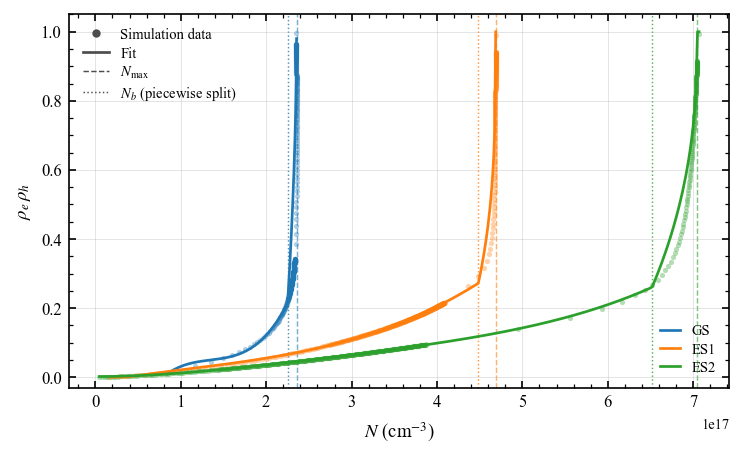

In [31]:
"""
fit_occupation_saturation_piecewise_v2.py

Improved fitter for the rho_e * rho_h vs N curves (GS / ES1 / ES2) produced
by the QD rate-equation model. This is a revision of
fit_occupation_saturation_piecewise.py that targets the specific ways the
previous version was under-fitting sharply-kneed saturation curves.

WHAT CHANGED VS. THE PREVIOUS VERSION, AND WHY
------------------------------------------------
1. NB_OVERRIDES bug fixed.
   The previous driver defined a per-level manual-breakpoint dictionary
   but then called `fit_level(x, y, level, Nb_override=None)` for every
   level -- the override was built and never used. Fixed here: the driver
   now actually passes NB_OVERRIDES[level].

2. New single-function model: delayed_power_saturation.
   Looking at the actual curve shapes (long near-flat stretch, then a
   sudden near-vertical rise to the Pauli-blocking ceiling), a lot of the
   "need" for a piecewise split was really a signal that the whole-curve
   model family was too limited -- none of power_saturation /
   weibull_saturation / generalized_logistic / rational_pade / exp_naive
   can represent a *hard, flat delay* before the rise starts, only a
   gradual one. delayed_power_saturation(xm, u0, n) adds an explicit
   "nothing happens until u0*xm, then a power-law rise to the ceiling"
   shape, which is a much closer match and often fits the *whole* curve
   well without any split at all.

3. New single-function model: skew_logistic.
   generalized_logistic(xm, n) is antisymmetric about u=0.5 (same
   sharpness on both sides of the inflection). skew_logistic(xm, n1, n2)
   allows independent low-u and high-u exponents, so it can be gentle
   near 0 and very sharp near the ceiling -- exactly the asymmetric shape
   these curves show.

4. Ceiling-aware weighting.
   All of these curves have most of their *data points* sitting in the
   long, boring, near-zero stretch, and only a handful of points near the
   near-vertical approach to y=1 -- which is exactly the region that
   determines the physically important quantity, N_max. Unweighted
   least-squares in y barely "feels" errors there (a few points, each
   with small (1-y)) and happily sacrifices ceiling accuracy to shave
   residual off the flat part. Every fit here is now done with
   sigma_i = clip(1 - y_i, WEIGHT_FLOOR, 1.0) passed to curve_fit, so
   points close to saturation are weighted up (smaller sigma = more
   weight) and the optimizer is forced to get the approach to the
   ceiling right.

5. Breakpoint is now found by direct search, not a single heuristic jump.
   The previous find_breakpoint() picked the single largest jump in y
   between consecutive sorted points. For adaptively-sampled data this
   very often lands right next to N_max itself (where consecutive-point
   jumps in y are naturally largest simply because the curve is nearly
   vertical there), starving segment 2 of the points it needs to
   constrain its own shape -- which is exactly the failure mode that
   forced a manual NB_OVERRIDES entry for GS in the previous script.
   optimize_breakpoint() instead tries a grid of candidate breakpoints
   (respecting a minimum-points-per-side margin), fits both segments at
   each candidate, and keeps the Nb that minimizes the *actual* combined
   weighted fit error -- i.e. the breakpoint is chosen by how well it
   lets both pieces fit, not by a shape heuristic.

6. Single-vs-piecewise choice is now by AIC, not a fixed R^2 threshold.
   A fixed R2_THRESHOLD is arbitrary and doesn't account for the extra
   free parameters (including Nb itself) a piecewise model spends to buy
   its improvement. Piecewise is now only kept if it beats the best
   single-function fit by a meaningful AIC margin (default: 6), charging
   the piecewise model for its extra parameters including the breakpoint
   itself. This also means a curve like ES2 -- which in the data provided
   never actually reaches its ceiling -- won't be force-split just
   because no single function gets a perfect R^2; it'll keep whichever
   description (single or piecewise) is genuinely better supported.

USAGE
-----
Exactly as before -- compute your N_e_gs / rho_h_gs_arr etc. arrays, then
run this file (or import fit_level / plot_results from it). Nothing else
needs to change unless your variable names differ.
"""

import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ----------------------------------------------------------------------
# Config
# ----------------------------------------------------------------------
VOLUME = 40e-3
X_UNIT_LABEL = r"cm$^{-3}$"
OUT_BASENAME = "occupation_saturation_piecewise_v2_fits"
LEVEL_COLORS = {"GS": "tab:blue", "ES1": "tab:orange", "ES2": "tab:green"}

# Ceiling-aware weighting: sigma_i = clip(1 - y_i, WEIGHT_FLOOR, 1.0).
# Smaller floor = more aggressive up-weighting of near-saturation points.
WEIGHT_FLOOR = 0.02

# Piecewise is only kept if it beats the best single-function fit by at
# least this much AIC (lower AIC is better). Larger = more conservative
# about splitting.
AIC_SPLIT_MARGIN = 6.0

# If the best single-function (weighted) R^2 already clears this bar,
# keep it outright and don't even run the breakpoint search: with
# ceiling-aware weighting, AIC comparisons get hypersensitive to
# vanishingly small residual differences once a fit is already this
# good, and can "prefer" a piecewise split that buys no real accuracy
# at the cost of a much messier PICWave expression.
SINGLE_GOOD_ENOUGH_R2 = 0.999

# Minimum number of points required on each side of any candidate
# breakpoint, so segment 2 always has enough points to constrain its own
# shape (this is what the previous jump-heuristic could violate).
MIN_SEG_POINTS = None  # None -> max(6, 5% of points), set per-call

GOLDEN_RATIO = 1.618
FIG_WIDTH_IN = 5.0
FIG_HEIGHT_IN = FIG_WIDTH_IN / GOLDEN_RATIO

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 8,
    "axes.labelsize": 9,
    "axes.linewidth": 0.8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "legend.fontsize": 7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# ----------------------------------------------------------------------
# Small utilities
# ----------------------------------------------------------------------

def _clean_sort(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y) & (x >= 0)
    x, y = x[mask], y[mask]
    order = np.argsort(x)
    return x[order], y[order]


def _sigma_weights(y):
    """Ceiling-aware sigma for curve_fit: small near y=1 (more weight),
    ~1 near y=0 (default weight)."""
    return np.clip(1.0 - y, WEIGHT_FLOOR, 1.0)


def _wrss(y, y_fit, sigma):
    return np.sum(((y - y_fit) / sigma) ** 2)


def _aic_w(y, y_fit, sigma, k):
    """Weighted-least-squares AIC surrogate: n*log(WRSS/n) + 2k."""
    n = len(y)
    wrss = _wrss(y, y_fit, sigma)
    return n * np.log(wrss / n + 1e-300) + 2 * k


def _r2(y, y_fit):
    ss_res = np.sum((y - y_fit) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot > 0 else np.nan


def _min_seg_points(n_total):
    return max(6, int(round(0.05 * n_total)))


def _xm_bounds(x, y, y_saturated_thresh=0.97):
    """Bounds for the ceiling parameter xm, chosen from the data instead
    of hard-pinning xm >= x.max(). If the curve already reaches close to
    1 somewhere in the data, the true ceiling can legitimately sit BELOW
    the highest simulated N (there's 'plateau' data past the knee) -- the
    old fixed bound x.max()*1.0001 made that architecturally impossible
    and silently forced bad fits on exactly this kind of curve. If the
    curve never gets close to 1, the ceiling must lie beyond the data, so
    we still require xm > x.max() in that case."""
    xmax = x.max()
    if np.any(y >= y_saturated_thresh):
        # ceiling is (at least nearly) reached inside the data -- let it
        # be found anywhere in a broad window around where that happens
        lo = 0.3 * xmax
        hi = 1.5 * xmax
    else:
        lo = xmax * 1.0001
        hi = xmax * 5.0
    return lo, hi


# ----------------------------------------------------------------------
# Whole-curve candidate models -- u = x/xm in [0,1), y(0)=0, y->1 as
# x -> xm^-.
# ----------------------------------------------------------------------

def model_power_saturation(x, xm, n):
    u = np.clip(x / xm, 0, 1 - 1e-12)
    return 1 - (1 - u) ** n


def model_weibull_saturation(x, xm, k, n):
    u = np.clip(x / xm, 0, 1 - 1e-12)
    return 1 - np.exp(-k * (u / (1 - u)) ** n)


def model_generalized_logistic(x, xm, n):
    u = np.clip(x / xm, 1e-12, 1 - 1e-12)
    return u ** n / (u ** n + (1 - u) ** n)


def model_rational_pade(x, xm, a):
    u = np.clip(x / xm, 0, 1 - 1e-12)
    return u / (a + (1 - a) * u)


def model_exp_naive(x, k):
    return 1 - np.exp(-k * x)


def model_delayed_power_saturation(x, xm, u0, n):
    """Flat at 0 until u0*xm, then a power-law rise to 1 at xm.
    Captures a genuine 'nothing happens, then it happens fast' knee as a
    single smooth-enough function -- often removes the need to split."""
    u = np.clip(x / xm, 0, 1 - 1e-12)
    u0c = np.clip(u0, 0, 0.999)
    rise = np.clip((u - u0c) / (1 - u0c), 0, 1)
    return rise ** n


def model_skew_logistic(x, xm, n1, n2):
    """Like generalized_logistic but with independent low-u / high-u
    exponents, so it can be gentle near 0 and very sharp near the
    ceiling instead of forced to be symmetric."""
    u = np.clip(x / xm, 1e-12, 1 - 1e-12)
    return u ** n1 / (u ** n1 + (1 - u) ** n2)


WHOLE_MODELS = {
    "power_saturation": dict(
        func=model_power_saturation, pnames=["xm", "n"],
        p0=lambda x, y: [max(1.05 * x.max(), _xm_bounds(x, y)[0] * 1.05), 0.1],
        bounds=lambda x, y=None: ([_xm_bounds(x, y)[0], 1e-3], [_xm_bounds(x, y)[1], 20]),
    ),
    "weibull_saturation": dict(
        func=model_weibull_saturation, pnames=["xm", "k", "n"],
        p0=lambda x, y: [max(1.05 * x.max(), _xm_bounds(x, y)[0] * 1.05), 1.0, 1.0],
        bounds=lambda x, y=None: ([_xm_bounds(x, y)[0], 1e-4, 1e-3],
                                  [_xm_bounds(x, y)[1], 1e3, 15]),
    ),
    "generalized_logistic": dict(
        func=model_generalized_logistic, pnames=["xm", "n"],
        p0=lambda x, y: [max(1.05 * x.max(), _xm_bounds(x, y)[0] * 1.05), 0.3],
        bounds=lambda x, y=None: ([_xm_bounds(x, y)[0], 1e-3], [_xm_bounds(x, y)[1], 25]),
    ),
    "rational_pade": dict(
        func=model_rational_pade, pnames=["xm", "a"],
        p0=lambda x, y: [max(1.05 * x.max(), _xm_bounds(x, y)[0] * 1.05), 0.1],
        bounds=lambda x, y=None: ([_xm_bounds(x, y)[0], 1e-4], [_xm_bounds(x, y)[1], 1]),
    ),
    "exp_naive": dict(
        func=model_exp_naive, pnames=["k"],
        p0=lambda x, y: [1.0 / x.max()],
        bounds=lambda x, y=None: ([1e-25], [1e-10]),
    ),
    "delayed_power_saturation": dict(
        func=model_delayed_power_saturation, pnames=["xm", "u0", "n"],
        # Multi-start: this model has a real local-optimum risk (u0 and n
        # trade off against each other), so seed several plausible onset
        # points / steepnesses, at both a "ceiling within the data" xm
        # guess and a "ceiling beyond the data" xm guess.
        p0=lambda x, y: [[xm0, u0, n]
                          for xm0 in (0.7 * x.max(), 1.05 * x.max())
                          for u0 in (0.2, 0.4, 0.6, 0.8)
                          for n in (1.0, 3.0, 8.0)],
        bounds=lambda x, y=None: ([_xm_bounds(x, y)[0], 0.0, 0.2],
                                  [_xm_bounds(x, y)[1], 0.98, 30]),
    ),
    "skew_logistic": dict(
        func=model_skew_logistic, pnames=["xm", "n1", "n2"],
        p0=lambda x, y: [[xm0, n1, n2]
                          for xm0 in (0.7 * x.max(), 1.05 * x.max())
                          for n1 in (1.0, 3.0, 8.0)
                          for n2 in (3.0, 8.0, 20.0)],
        bounds=lambda x, y=None: ([_xm_bounds(x, y)[0], 1e-2, 1e-2],
                                  [_xm_bounds(x, y)[1], 25, 40]),
    ),
}


def _is_multi_start(p0):
    """True if p0 is a list of candidate seed vectors rather than one."""
    return len(p0) > 0 and isinstance(p0[0], (list, tuple, np.ndarray))


def _fit_with_best_start(func, x, y, p0, bounds, sigma, maxfev=30000):
    """Try one or several p0 seeds (see _is_multi_start) and return the
    (popt, y_fit) with the lowest weighted RSS across all seeds that
    converge. Raises RuntimeError if every seed fails."""
    seeds = p0 if _is_multi_start(p0) else [p0]
    best = None
    for seed in seeds:
        try:
            popt, _ = curve_fit(func, x, y, p0=seed, bounds=bounds,
                                 sigma=sigma, maxfev=maxfev)
            y_fit = func(x, *popt)
            wrss = _wrss(y, y_fit, sigma)
            if best is None or wrss < best[2]:
                best = (popt, y_fit, wrss)
        except Exception:
            continue
    if best is None:
        raise RuntimeError("all seeds failed to converge")
    return best[0], best[1]

SEG1_MODEL_NAMES = ["generalized_logistic", "rational_pade", "exp_naive",
                     "delayed_power_saturation"]


def whole_curve_formula(name, popt):
    """PICWave-syntax string (no spaces, exp()/** literal, numbers
    plugged in) for a whole-curve model. Also used for segment 1."""
    if name == "power_saturation":
        xm, n = popt
        return f"1-(1-N/{xm:.6e})**{n:.4f}"
    if name == "weibull_saturation":
        xm, k, n = popt
        return (f"1-exp(-{k:.6e}*((N/{xm:.6e})/"
                 f"max(1e-12,1-N/{xm:.6e}))**{n:.4f})")
    if name == "generalized_logistic":
        xm, n = popt
        return f"N**{n:.4f}/(N**{n:.4f}+({xm:.6e}-N)**{n:.4f})"
    if name == "rational_pade":
        xm, a = popt
        return f"N/({a:.6f}*{xm:.6e}+{1 - a:.6f}*N)"
    if name == "exp_naive":
        (k,) = popt
        return f"1-exp(-{k:.6e}*N)"
    if name == "delayed_power_saturation":
        xm, u0, n = popt
        Nb = u0 * xm
        return (f"if(N<{Nb:.6e},0,"
                f"min(1,max(0,((N/{xm:.6e}-{u0:.6f})/{1 - u0:.6f})**{n:.4f})))")
    if name == "skew_logistic":
        xm, n1, n2 = popt
        xm_pow = xm ** (n1 - n2)
        return (f"N**{n1:.4f}/(N**{n1:.4f}+({xm:.6e}-N)**{n2:.4f}*{xm_pow:.6e})")
    raise ValueError(f"unknown model {name}")


# ----------------------------------------------------------------------
# Whole-curve fit (weighted)
# ----------------------------------------------------------------------

def fit_whole_curve(x, y, verbose_name=None):
    x, y = _clean_sort(x, y)
    sigma = _sigma_weights(y)
    results = {}
    for name, spec in WHOLE_MODELS.items():
        try:
            p0 = spec["p0"](x, y)
            bounds = spec["bounds"](x, y)
            popt, y_fit = _fit_with_best_start(spec["func"], x, y, p0,
                                                bounds, sigma)
            results[name] = dict(popt=popt, r2=_r2(y, y_fit),
                                  aic=_aic_w(y, y_fit, sigma, len(popt)))
        except Exception as e:
            results[name] = dict(popt=None, r2=-np.inf, aic=np.inf,
                                  error=str(e))

    ranked = sorted(results.items(), key=lambda kv: kv[1]["aic"])
    best_name, best = ranked[0]

    if verbose_name:
        print(f"\n=== {verbose_name}: whole-curve candidates (weighted) ===")
        for name, r in sorted(results.items(), key=lambda kv: -kv[1]["r2"]):
            tag = " <== best (lowest AIC)" if name == best_name else ""
            if r["popt"] is None:
                print(f"  {name:26s}  FAILED ({r.get('error')})")
            else:
                params = ", ".join(f"{p:.4g}" for p in r["popt"])
                print(f"  {name:26s}  R^2={r['r2']:.6f}  AIC={r['aic']:.2f}"
                      f"  params=[{params}]{tag}")

    return best_name, best, ranked, x, y


# ----------------------------------------------------------------------
# poly1d segment-1 candidate (native PICWave function)
# ----------------------------------------------------------------------

def _poly_fit(x, y, deg, sigma=None):
    xmin, xmax = x.min(), x.max()
    scale = xmax - xmin if xmax > xmin else 1.0
    xn = (x - xmin) / scale
    w = None if sigma is None else 1.0 / sigma
    c = np.polyfit(xn, y, deg, w=w)[::-1]
    y_fit = np.polyval(c[::-1], xn)
    r2 = _r2(y, y_fit)
    sig = sigma if sigma is not None else np.ones_like(y)
    aic = _aic_w(y, y_fit, sig, deg + 1)
    return dict(xmin=xmin, scale=scale, coeffs=c, r2=r2, aic=aic)


def _poly_formula(xmin, scale, coeffs):
    terms = ", ".join(f"{c:.6e}" for c in coeffs)
    return f"poly1d((N-{xmin:.6e})/{scale:.6e}, {terms})"


def _poly_eval(N, xmin, scale, coeffs):
    xn = (np.asarray(N, dtype=float) - xmin) / scale
    return np.polyval(coeffs[::-1], xn)


def fit_segment1(x, y, verbose=True):
    """Best local (weighted) fit for the gentle pre-knee portion."""
    sigma = _sigma_weights(y)
    candidates = []
    x_test = np.linspace(x.min(), x.max(), 200)

    for name in SEG1_MODEL_NAMES:
        spec = WHOLE_MODELS[name]
        try:
            p0 = spec["p0"](x, y)
            bounds = spec["bounds"](x, y)
            popt, _ = _fit_with_best_start(spec["func"], x, y, p0, bounds, sigma)
            y_test = spec["func"](x_test, *popt)
            if np.any(np.diff(y_test) < -1e-4):
                if verbose:
                    print(f"  [{name}] segment-1 fit rejected: non-monotonic")
                continue
            y_fit = spec["func"](x, *popt)
            candidates.append(dict(
                name=name, r2=_r2(y, y_fit), aic=_aic_w(y, y_fit, sigma, len(popt)),
                formula=whole_curve_formula(name, popt),
                eval_fn=lambda N, fn=spec["func"], popt=popt: fn(N, *popt),
            ))
        except Exception as e:
            if verbose:
                print(f"  [{name}] segment-1 fit failed: {e}")

    for deg in (3, 4):
        try:
            pf = _poly_fit(x, y, deg, sigma=sigma)
            y_test = _poly_eval(x_test, pf["xmin"], pf["scale"], pf["coeffs"])
            if np.any(np.diff(y_test) < -1e-4):
                if verbose:
                    print(f"  [poly{deg}] segment-1 fit rejected: non-monotonic")
                continue
            candidates.append(dict(
                name=f"poly{deg}", r2=pf["r2"], aic=pf["aic"],
                formula=_poly_formula(pf["xmin"], pf["scale"], pf["coeffs"]),
                eval_fn=lambda N, pf=pf: _poly_eval(N, pf["xmin"], pf["scale"], pf["coeffs"]),
            ))
        except Exception as e:
            if verbose:
                print(f"  [poly{deg}] segment-1 fit failed: {e}")

    if not candidates:
        if verbose:
            print("  WARNING: all seg-1 candidates failed/rejected. Falling back to linear.")
        pf = _poly_fit(x, y, 1, sigma=sigma)
        return dict(
            name="poly1", r2=pf["r2"], aic=pf["aic"],
            formula=_poly_formula(pf["xmin"], pf["scale"], pf["coeffs"]),
            eval_fn=lambda N, pf=pf: _poly_eval(N, pf["xmin"], pf["scale"], pf["coeffs"]),
        )

    candidates.sort(key=lambda c: c["aic"])
    if verbose:
        print("  -- segment 1 candidates (monotonic only, weighted) --")
        for c in candidates:
            print(f"  {c['name']:<26}{c['r2']:>10.5f}{c['aic']:>12.2f}")
    return candidates[0]


# ----------------------------------------------------------------------
# Segment-2 (post-knee) models, anchored so y(N_b) = y_break exactly.
# ----------------------------------------------------------------------

def anchored_power_saturation_rise(N, Nb, y_break, W, n):
    u = np.clip((N - Nb) / W, 0, 1 - 1e-12)
    return 1 - (1 - y_break) * (1 - u) ** n


def anchored_weibull_rise(N, Nb, y_break, W, k, n):
    u = np.clip((N - Nb) / W, 0, 1 - 1e-12)
    return 1 - (1 - y_break) * np.exp(-k * (u / (1 - u)) ** n)


def anchored_generalized_logistic_rise(N, Nb, y_break, W, n):
    u = np.clip((N - Nb) / W, 1e-12, 1 - 1e-12)
    g = u ** n / (u ** n + (1 - u) ** n)
    return y_break + (1 - y_break) * g


def anchored_exp_rise(N, Nb, y_break, W):
    return 1 - (1 - y_break) * np.exp(-(N - Nb) / W)


SEG2_MODELS = {
    "anchored_power_saturation_rise": (anchored_power_saturation_rise, ["W", "n"]),
    "anchored_weibull_rise":          (anchored_weibull_rise,          ["W", "k", "n"]),
    "anchored_generalized_logistic_rise": (anchored_generalized_logistic_rise, ["W", "n"]),
    "anchored_exp_rise":              (anchored_exp_rise,              ["W"]),
}
SEG2_P0 = {
    "anchored_power_saturation_rise": lambda x, Nb: [(x.max() - Nb) * 1.05, 0.3],
    "anchored_weibull_rise":          lambda x, Nb: [(x.max() - Nb) * 1.05, 1.0, 1.0],
    "anchored_generalized_logistic_rise": lambda x, Nb: [(x.max() - Nb) * 1.05, 0.3],
    "anchored_exp_rise":              lambda x, Nb: [(x.max() - Nb) * 0.3],
}
SEG2_BOUNDS = {
    "anchored_power_saturation_rise": ([1e-10, 1e-3], [np.inf, 5.0]),
    "anchored_weibull_rise":          ([1e-10, 1e-4, 1e-3], [np.inf, 1e3, 15]),
    "anchored_generalized_logistic_rise": ([1e-10, 1e-3], [np.inf, 25]),
    "anchored_exp_rise":              ([1e-10], [np.inf]),
}


def _seg2_formula(name, Nb, y_break, popt):
    if name == "anchored_power_saturation_rise":
        W, n = popt
        return (f"1-{1 - y_break:.6f}*max(1e-12,1-(N-{Nb:.6e})/{W:.6e})"
                f"**{n:.4f}")
    if name == "anchored_weibull_rise":
        W, k, n = popt
        return (f"1-{1 - y_break:.6f}*exp(-{k:.6e}*(((N-{Nb:.6e})/{W:.6e})/"
                f"max(1e-12,1-(N-{Nb:.6e})/{W:.6e}))**{n:.4f})")
    if name == "anchored_generalized_logistic_rise":
        W, n = popt
        Nmax = Nb + W
        return (f"{y_break:.6f}+{1 - y_break:.6f}*(N-{Nb:.6e})**{n:.4f}/"
                f"((N-{Nb:.6e})**{n:.4f}+({Nmax:.6e}-N)**{n:.4f})")
    if name == "anchored_exp_rise":
        (W,) = popt
        return f"1-{1 - y_break:.6f}*exp(-(N-{Nb:.6e})/{W:.6e})"
    raise ValueError(f"unknown segment-2 model {name}")


def _fit_pieces_at_breakpoint(xs, ys, i, verbose=False):
    """Fit segment 1 (<= i) and anchored segment 2 (>= i) for a candidate
    breakpoint index i. Returns None if either side fails."""
    Nb = xs[i]
    seg1_x, seg1_y = xs[:i + 1], ys[:i + 1]
    seg2_x, seg2_y = xs[i:], ys[i:]

    try:
        seg1 = fit_segment1(seg1_x, seg1_y, verbose=verbose)
    except Exception:
        return None
    y_break = float(np.atleast_1d(seg1["eval_fn"](np.array([Nb])))[0])
    y_break = float(np.clip(y_break, 0, 1 - 1e-6))

    sigma2 = _sigma_weights(seg2_y[1:])
    best = None
    for name, (fn, pnames) in SEG2_MODELS.items():
        try:
            def wrapped(N, *p, fn=fn):
                return fn(N, Nb, y_break, *p)
            p0 = SEG2_P0[name](seg2_x, Nb)
            popt, _ = curve_fit(wrapped, seg2_x[1:], seg2_y[1:], p0=p0,
                                 bounds=SEG2_BOUNDS[name], sigma=sigma2,
                                 maxfev=30000)
            yfit = wrapped(seg2_x[1:], *popt)
            aic = _aic_w(seg2_y[1:], yfit, sigma2, len(popt))
            r2 = _r2(seg2_y[1:], yfit)
            if best is None or aic < best[3]:
                best = (name, popt, r2, aic, fn)
        except Exception:
            continue
    if best is None:
        return None
    name2, popt2, r2_2, aic2, fn2 = best

    # total combined AIC, charging one extra parameter for Nb itself
    yfit_all = np.concatenate([seg1["eval_fn"](seg1_x), fn2(seg2_x[1:], Nb, y_break, *popt2)])
    y_all = np.concatenate([seg1_y, seg2_y[1:]])
    sigma_all = _sigma_weights(y_all)
    k_total = len(popt2) + 1  # seg1's own params already scored in seg1["aic"]; +1 for Nb
    combined_aic = _aic_w(y_all, yfit_all, sigma_all, k_total)
    # fold in the seg1 model's own parameter count via its own aic contribution:
    # simplest robust approach -- recompute a single AIC over the *whole* curve
    n_total = len(y_all)
    wrss_total = _wrss(y_all, yfit_all, sigma_all)
    seg1_k = {"generalized_logistic": 2, "rational_pade": 2, "exp_naive": 1,
              "delayed_power_saturation": 3, "poly3": 4, "poly4": 5,
              "poly1": 2}.get(seg1["name"], 2)
    k_full = seg1_k + len(popt2) + 1  # +1 for the breakpoint itself
    aic_full = n_total * np.log(wrss_total / n_total + 1e-300) + 2 * k_full

    return dict(
        Nb=Nb, y_break=y_break, seg1=seg1, seg2_name=name2, seg2_popt=popt2,
        seg2_r2=r2_2, seg2_fn=fn2, aic_full=aic_full, r2_combined=_r2(y_all, yfit_all),
        y_all=y_all, yfit_all=yfit_all,
    )


def optimize_breakpoint(x, y, min_segment_points=None, n_grid=18, verbose=True):
    """Grid-search the breakpoint: try candidate indices (respecting a
    minimum-points-per-side margin), fit both segments at each, and keep
    whichever candidate gives the lowest combined AIC. This replaces the
    old 'largest single jump in y' heuristic, which tends to land right
    next to N_max and starve segment 2 of points."""
    xs, ys = _clean_sort(x, y)
    n = len(xs)
    if min_segment_points is None:
        min_segment_points = _min_seg_points(n)

    lo = min_segment_points
    hi = n - min_segment_points
    if hi <= lo:
        lo, hi = 1, n - 2  # degenerate fallback for very short curves

    candidate_idx = sorted(set(np.linspace(lo, hi, min(n_grid, hi - lo + 1)).astype(int)))

    if verbose:
        print(f"  scanning {len(candidate_idx)} candidate breakpoints "
              f"in index range [{lo}, {hi}] out of {n} points...")

    scored = []
    for i in candidate_idx:
        res = _fit_pieces_at_breakpoint(xs, ys, i, verbose=False)
        if res is not None:
            scored.append((i, res))

    if not scored:
        return None

    scored.sort(key=lambda t: t[1]["aic_full"])
    best_i, best_res = scored[0]

    # local refinement: rescan +/- one grid step around the coarse winner
    idx_pos = candidate_idx.index(best_i)
    lo_ref = candidate_idx[max(0, idx_pos - 1)]
    hi_ref = candidate_idx[min(len(candidate_idx) - 1, idx_pos + 1)]
    fine_idx = range(lo_ref, hi_ref + 1)
    for i in fine_idx:
        if i in dict(scored):
            continue
        res = _fit_pieces_at_breakpoint(xs, ys, i, verbose=False)
        if res is not None:
            scored.append((i, res))

    scored.sort(key=lambda t: t[1]["aic_full"])
    best_i, best_res = scored[0]

    if verbose:
        print(f"  breakpoint search: best N_b index={best_i}  "
              f"N_b={xs[best_i]:.5e}  combined AIC={best_res['aic_full']:.2f}  "
              f"combined R^2={best_res['r2_combined']:.5f}")

    return best_i, best_res, xs, ys


def build_piecewise_result(idx_res_xs_ys, title=""):
    i, res, xs, ys = idx_res_xs_ys
    Nb = res["Nb"]
    y_break = res["y_break"]
    seg1 = res["seg1"]
    name2 = res["seg2_name"]
    popt2 = res["seg2_popt"]
    fn2 = res["seg2_fn"]

    seg1_formula = seg1["formula"]
    seg2_formula = _seg2_formula(name2, Nb, y_break, popt2)
    inner_expr = f"if(N<{Nb:.6e},{seg1_formula},{seg2_formula})"
    # Hard-clamp to exactly 0 at/below N=0: don't rely on the chosen
    # segment-1 model happening to pass through the origin (a poly3/poly4
    # segment-1 candidate in particular has no such guarantee).
    picwave_expr = f"if(N<=0,0,min(1,max(0,{inner_expr})))"

    W_fit = popt2[0]
    Nmax = Nb + W_fit if name2 != "anchored_exp_rise" else None

    print(f"\n=== {title} (piecewise, optimized breakpoint) ===")
    print(f"  N_b = {Nb:.5e}   y_break = {y_break:.5f}")
    print(f"  segment 1: {seg1['name']}  (local R^2={seg1['r2']:.5f})")
    print(f"  segment 2: {name2}  (local R^2={res['seg2_r2']:.5f})")
    if Nmax is not None:
        print(f"  fitted Pauli-blocking ceiling N_max = {Nmax:.5e}")
    else:
        print("  NOTE: segment-2 model has no finite ceiling "
              "(asymptotic approach to 1 only).")
    print(f"  combined weighted-fit R^2 = {res['r2_combined']:.5f}, "
          f"AIC={res['aic_full']:.2f}")

    def predict(N_query):
        N_query = np.asarray(N_query, dtype=float)
        out = np.empty_like(N_query)
        mask = N_query < Nb
        if np.any(mask):
            out[mask] = seg1["eval_fn"](N_query[mask])
        if np.any(~mask):
            out[~mask] = fn2(N_query[~mask], Nb, y_break, *popt2)
        out = np.clip(out, 0, 1)
        out = np.where(N_query <= 0, 0.0, out)
        return out

    return dict(
        Nb=Nb, y_break=y_break, seg1_name=seg1["name"], seg1_r2=seg1["r2"],
        seg1_formula=seg1_formula, seg2_name=name2, seg2_r2=res["seg2_r2"],
        seg2_formula=seg2_formula, seg2_popt=popt2, Nmax=Nmax,
        r2_combined=res["r2_combined"], aic_full=res["aic_full"],
        picwave_expr=picwave_expr, predict=predict, x_data=xs, y_data=ys,
    )


# ----------------------------------------------------------------------
# Driver: fit whole curve, fit best piecewise (optimized breakpoint), and
# keep whichever wins on AIC (with a margin, so splitting has to earn its
# extra parameters).
# ----------------------------------------------------------------------

def fit_level(x, y, level_name, Nb_override=None):
    best_name, best, ranked, xs, ys = fit_whole_curve(x, y, verbose_name=level_name)
    whole_aic = best["aic"]

    good_enough = (Nb_override is None) and (best["r2"] >= SINGLE_GOOD_ENOUGH_R2)

    if good_enough:
        print(f"\n{level_name}: single-function R^2={best['r2']:.6f} >= "
              f"{SINGLE_GOOD_ENOUGH_R2} -> keeping it outright, skipping "
              f"breakpoint search.")
        opt = None
        piecewise_aic = np.inf
    elif Nb_override is not None:
        idx = int(np.argmin(np.abs(xs - Nb_override)))
        piecewise_raw = _fit_pieces_at_breakpoint(xs, ys, idx, verbose=True)
        opt = (idx, piecewise_raw, xs, ys) if piecewise_raw is not None else None
        print(f"\n{level_name}: using user-forced N_b_override={Nb_override:.4g}")
        piecewise_aic = opt[1]["aic_full"] if opt is not None else np.inf
    else:
        opt = optimize_breakpoint(xs, ys)
        piecewise_aic = opt[1]["aic_full"] if opt is not None else np.inf

    use_piecewise = (not good_enough) and (
        (Nb_override is not None) or (piecewise_aic < whole_aic - AIC_SPLIT_MARGIN))

    if not use_piecewise:
        formula = whole_curve_formula(best_name, best["popt"])
        func = WHOLE_MODELS[best_name]["func"]
        popt = best["popt"]
        Nmax = None
        if best_name in ("power_saturation", "weibull_saturation",
                          "generalized_logistic", "rational_pade",
                          "delayed_power_saturation", "skew_logistic"):
            Nmax = popt[0]

        def predict(N_query, func=func, popt=popt):
            N_query = np.asarray(N_query, dtype=float)
            out = np.clip(func(N_query, *popt), 0, 1)
            return np.where(N_query <= 0, 0.0, out)

        # Hard-clamp to exactly 0 at/below N=0 (belt-and-braces: every
        # model here already evaluates to ~0 at N=0 mathematically, but
        # this removes any dependence on that and protects against
        # negative-N extrapolation/edge cases).
        picwave_expr = f"if(N<=0,0,min(1,max(0,{formula})))"
        print(f"\n{level_name}: KEEPING single-function fit "
              f"({best_name}, AIC={whole_aic:.2f}"
              + (f" vs piecewise AIC={piecewise_aic:.2f}" if opt is not None else "")
              + f") -> no split needed.")
        return dict(kind="single", model=best_name, r2=best["r2"],
                    Nmax=Nmax, picwave_expr=picwave_expr, predict=predict,
                    x_data=xs, y_data=ys)

    print(f"\n{level_name}: piecewise AIC={piecewise_aic:.2f} beats single "
          f"AIC={whole_aic:.2f} (margin={AIC_SPLIT_MARGIN}) -> splitting.")
    pw = build_piecewise_result(opt, title=level_name)
    return dict(kind="piecewise", model=f"{pw['seg1_name']}+{pw['seg2_name']}",
                r2=pw["r2_combined"], Nmax=pw["Nmax"],
                picwave_expr=pw["picwave_expr"], predict=pw["predict"],
                x_data=xs, y_data=ys, Nb=pw["Nb"])


def plot_results(results):
    fig, ax = plt.subplots(figsize=(FIG_WIDTH_IN, FIG_HEIGHT_IN))
    for level, res in results.items():
        c = LEVEL_COLORS.get(level, "tab:gray")
        ax.plot(res["x_data"], res["y_data"], marker="o", ms=2.5,
                linestyle="None", color=c, alpha=0.35,
                markeredgewidth=0, zorder=2)
        x_smooth = np.linspace(res["x_data"].min(),
                                res["x_data"].max() * 0.999999, 400)
        ax.plot(x_smooth, res["predict"](x_smooth), "-", color=c,
                linewidth=1.3, zorder=3)
        if res.get("Nmax") is not None:
            ax.axvline(res["Nmax"], color=c, linestyle="--",
                        linewidth=0.7, alpha=0.6, zorder=1)
        if res["kind"] == "piecewise":
            ax.axvline(res["Nb"], color=c, linestyle=":",
                        linewidth=0.7, alpha=0.8, zorder=1)

    ax.set_xlabel(rf"$N$ ({X_UNIT_LABEL})")
    ax.set_ylabel(r"$\rho_e\,\rho_h$")
    ax.set_ylim(-0.03, 1.05)
    ax.grid(True, linewidth=0.4, alpha=0.4)
    ax.ticklabel_format(style="sci", axis="x", scilimits=(-2, 2))
    ax.xaxis.get_offset_text().set_fontsize(7)

    level_handles = [Line2D([0], [0], color=c, linewidth=1.3)
                      for c in LEVEL_COLORS.values()]
    legend_levels = ax.legend(level_handles, list(LEVEL_COLORS.keys()),
                               loc="lower right", frameon=False,
                               handlelength=1.4, labelspacing=0.3)
    ax.add_artist(legend_levels)

    style_handles = [
        Line2D([0], [0], color="0.3", marker="o", ms=3, linestyle="None"),
        Line2D([0], [0], color="0.3", linewidth=1.3),
        Line2D([0], [0], color="0.3", linestyle="--", linewidth=0.7),
        Line2D([0], [0], color="0.3", linestyle=":", linewidth=0.7),
    ]
    style_labels = ["Simulation data", "Fit",
                    r"$N_\mathrm{max}$", r"$N_b$ (piecewise split)"]
    ax.legend(style_handles, style_labels, loc="upper left", frameon=False,
              handlelength=1.8, labelspacing=0.3)

    fig.tight_layout()
    fig.savefig(f"{OUT_BASENAME}.png", dpi=600, bbox_inches="tight")
    fig.savefig(f"{OUT_BASENAME}.pdf", bbox_inches="tight")
    print(f"\nSaved {OUT_BASENAME}.png and {OUT_BASENAME}.pdf")


# ----------------------------------------------------------------------
# Run on your actual GS / ES1 / ES2 arrays (assumed already present in
# the notebook namespace -- nothing here is fabricated or simulated)
# ----------------------------------------------------------------------

x_gs = np.sum(N_e_gs, axis=1) / VOLUME
y_gs = np.mean(rho_h_gs_arr, axis=1) * np.mean(rho_e_gs_arr, axis=1)

x_es1 = np.sum(N_e_es1, axis=1) / VOLUME
y_es1 = np.mean(rho_h_es1_arr, axis=1) * np.mean(rho_e_es1_arr, axis=1)

x_es2 = np.sum(N_e_es2, axis=1) / VOLUME
y_es2 = np.mean(rho_h_es2_arr, axis=1) * np.mean(rho_e_es2_arr, axis=1)

LEVELS = {"GS": (x_gs, y_gs), "ES1": (x_es1, y_es1), "ES2": (x_es2, y_es2)}

# Configure custom breakpoints here. Set to None to use auto-detection.
NB_OVERRIDES = {
    "GS": 2.25e17,  # Adjust this to manually set the GS knee based on your specific dataset
    "ES1": 4.5E17,
    "ES2": 6.5E17,
}

results = {level: fit_level(x, y, level, Nb_override=NB_OVERRIDES.get(level)) 
           for level, (x, y) in LEVELS.items()}

plot_results(results)

print("\n\n=== Summary ===")
for level, res in results.items():
    nmax_str = f"{res['Nmax']:.4g}" if res.get("Nmax") is not None else "none (asymptotic)"
    print(f"{level:<4} -> kind={res['kind']:<9} model={res['model']:<40} "
          f"R^2={res['r2']:.5f}  N_max={nmax_str}")
    print(f"       PICWave: {level}(N)={res['picwave_expr']}")


=== GS: whole-curve candidates (weighted) ===
  power_saturation            R^2=0.895445  AIC=-1122.42  params=[2.355e+17, 0.1051] <== best (lowest AIC)
  delayed_power_saturation    R^2=0.729543  AIC=-952.70  params=[2.357e+17, 0.5662, 30]
  skew_logistic               R^2=0.601085  AIC=-937.13  params=[2.355e+17, 25, 0.1024]
  generalized_logistic        R^2=-1.393993  AIC=-360.15  params=[2.355e+17, 0.3226]
  rational_pade               R^2=-2.765612  AIC=-211.98  params=[2.521e+17, 1]
  weibull_saturation          R^2=-4.015755  AIC=1.07  params=[2.473e+17, 1, 1]
  exp_naive                   R^2=-4.105555  AIC=1.00  params=[5e-11]
  scanning 18 candidate breakpoints in index range [25, 475] out of 500 points...
  breakpoint search: best N_b index=141  N_b=2.30473e+17  combined AIC=-1061.80  combined R^2=0.87406

GS: KEEPING single-function fit (power_saturation, AIC=-1122.42 vs piecewise AIC=-1061.80) -> no split needed.

=== ES1: whole-curve candidates (weighted) ===
  power_sat

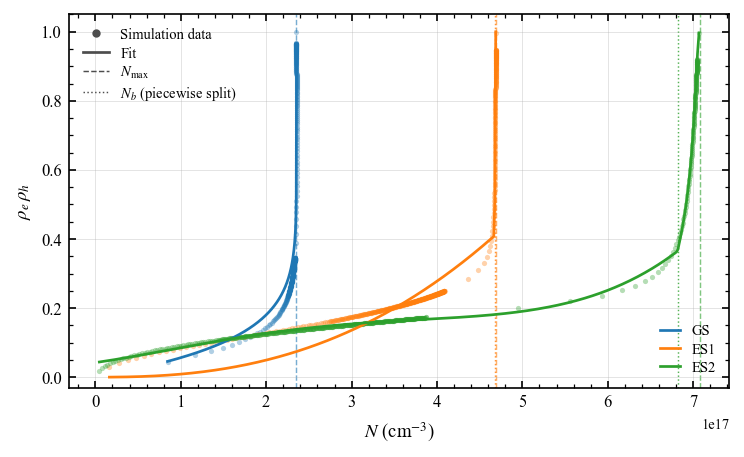

In [33]:
#USED IN SPONTANEOUS EMISSION CALCULATION

x_gs = np.sum(N_e_gs, axis=1) / VOLUME
y_gs = np.mean(rho_h_gs_arr, axis=1)

x_es1 = np.sum(N_e_es1, axis=1) / VOLUME
y_es1 = np.mean(rho_h_es1_arr, axis=1)

x_es2 = np.sum(N_e_es2, axis=1) / VOLUME
y_es2 = np.mean(rho_h_es2_arr, axis=1)

LEVELS = {"GS": (x_gs, y_gs), "ES1": (x_es1, y_es1), "ES2": (x_es2, y_es2)}

# Configure custom breakpoints here. Set to None to use auto-detection.
NB_OVERRIDES = {
    "GS": 2.1e17,  # Adjust this to manually set the GS knee based on your specific dataset
    "ES1": 4.2e17,
    "ES2": 6.8e17,
}

results = {level: fit_level(x, y, level, Nb_override=None) 
           for level, (x, y) in LEVELS.items()}

plot_results(results)

print("\n\n=== Summary ===")
for level, res in results.items():
    nmax_str = f"{res['Nmax']:.4g}" if res.get("Nmax") is not None else "none (asymptotic)"
    print(f"{level:<4} -> kind={res['kind']:<9} model={res['model']:<40} "
          f"R^2={res['r2']:.5f}  N_max={nmax_str}")
    print(f"       PICWave: {level}(N)={res['picwave_expr']}")


=== ES2 vs N_e_w ===
model                   R^2         AIC   f(N) =
power               0.99999    -6737.23   1/(1 + (N/4.076835e+16)**0.9757)
fermi2d             0.99993    -5938.73   1/(1 + (exp(N/1.620724e+21) - 1)*exp(10.5999))
stretched_exp       0.99794    -4263.31   exp(-(N/6.676728e+16)**0.7582)
power_saturation    0.98876    -3415.98   max(1e-12,1-N/2.918113e+17)**5.0000
shifted_sigmoid     0.98425    -3245.03   0.022464+(0.977536)/(1+exp((N-3.786765e+16)/2.132556e+16))
exp                 0.94076    -2586.71   exp(-N/4.108756e+16)
power_threshold     0.88950    -2273.01   1-(N/6.724669e+18)**0.1696
sigmoid             0.73162    -1829.32   1/(1 + exp((N-4.108756e+16)/8.217512e+15))
gen_richards        0.51353    -1525.94   -0.113445+(1.084164)/((1+1.882287*exp((N-4.108756e+16)/4.108756e+15))**0.531269)

=== ES1 vs sum(N_e_es2) ===
model                   R^2         AIC   f(N) =
stretched_exp       0.99491    -4302.82   exp(-(N/1.725671e+17)**0.9021)
fermi2d             0.

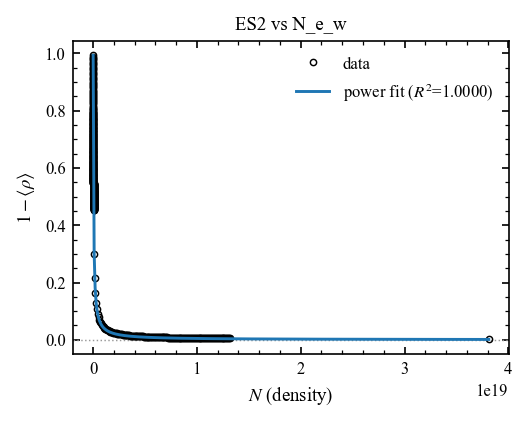

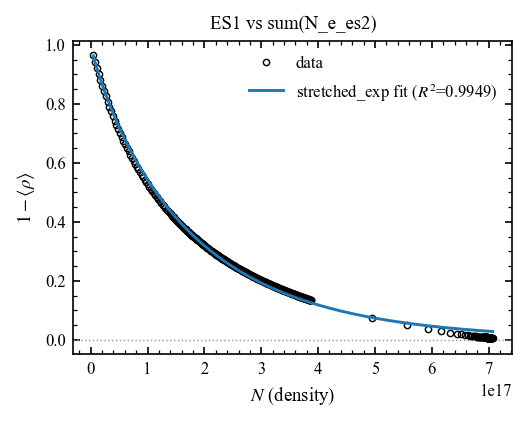

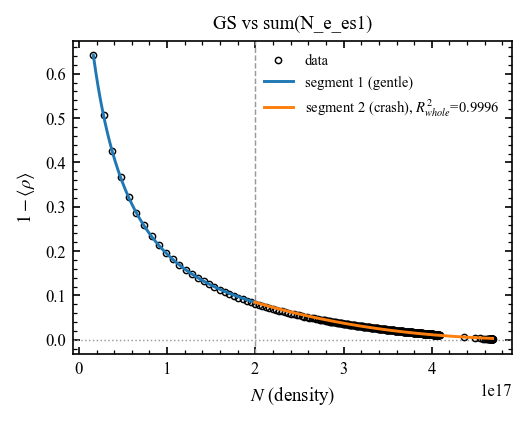

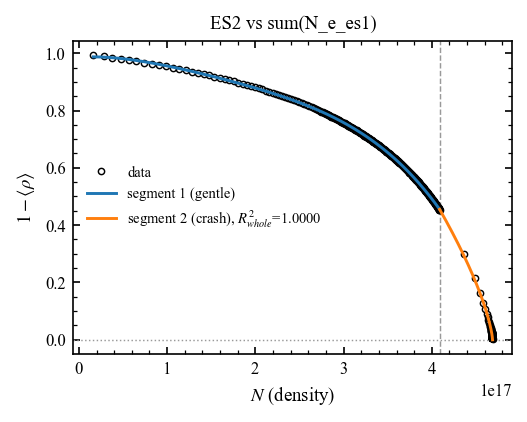

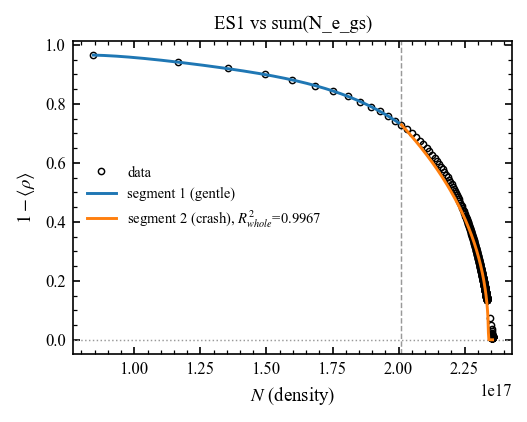



=== Summary (best model per curve) ===
ES2 vs N_e_w              -> power             R²=1.0000
    f(N)      = 1/(1 + (N/4.076835e+16)**0.9757)
    PICWave   = 1/(1 + (N/4.076835e+16)**0.9757)
ES1 vs sum(N_e_es2)       -> stretched_exp     R²=0.9949
    f(N)      = exp(-(N/1.725671e+17)**0.9021)
    PICWave   = exp(-(N/1.725671e+17)**0.9021)

=== Summary (piecewise curves) ===
GS vs sum(N_e_es1)        -> seg1=fermi2d (R²=0.9999)  seg2=anchored_power_saturation (R²=0.9943)  whole-curve R²=0.9996
    N_b       = 1.994170e+17
    PICWave   = if(N<1.994170e+17, 1/(1 + (exp(N/2.127919e+17) - 1)*exp(1.9396)), 0.084742*max(1e-12,1-(N-1.994170e+17)/3.750565e+17)**2.6164)
ES2 vs sum(N_e_es1)       -> seg1=poly4 (R²=0.9999)  seg2=anchored_power_saturation (R²=0.9987)  whole-curve R²=1.0000
    N_b       = 4.088225e+17
    PICWave   = if(N<4.088225e+17, poly1d((N-1.640052e+16)/3.924220e+17, 9.872321e-01, -7.591608e-03, -9.229889e-01, 1.427847e+00, -1.029396e+00), 0.455103*max(1e-12,1-(N-4.088

In [24]:
"""
Paste this directly after your existing plotting code. It reuses your
arrays as-is (N_e_w, rho_e_es2_arr, N_e_es2, rho_e_es1_arr, N_e_es1,
rho_e_gs_arr, N_e_gs) -- nothing to edit unless your variable names differ.

Fits each of the 5 curves from your two plots. Three of them (ES2 vs N_e_w,
ES1 vs sum(N_e_es2), GS vs sum(N_e_es1)) are fit with a single smooth
function as before, using the same 9-model AIC-ranked search.

The two problem curves - ES2 vs sum(N_e_es1) and ES1 vs sum(N_e_gs) - are
NOT single smooth functions: they decline gently over most of their range,
then crash to zero over a very short final stretch. No single sigmoid/power
law in the original candidate set can be both gentle-and-slow early on AND
have a near-vertical tangent at the end, which is exactly why they were
fitting poorly (R^2 = 0.93-0.95).

CHANGES vs the original version
--------------------------------
Those two curves are now fit as PIECEWISE functions:

  1. The breakpoint N_b is found automatically as the location of the
     single largest drop in y between consecutive (sorted) data points.
     This is more reliable than looking for the largest gap in N, because
     your solver's adaptive time-stepping already produces large N-gaps
     early in the curve (where dynamics are slow) -- the largest y-jump is
     what actually marks the knee where the physics changes character.

  2. Segment 1 (N < N_b, the gentle decline) is fit with the same
     model family as before, PLUS two new candidates:
       - shifted_sigmoid restricted to this sub-range (no longer needs to
         reach 0, so it fits the gentle part much better -- R^2 improves
         from ~0.83-0.96 to ~0.98-0.998 on your two problem curves)
       - poly1d (cubic/quartic), since PICWave has a native poly1d()
         function and a plain polynomial turns out to fit the "almost
         linear" gentle decline in ES1 vs sum(N_e_gs) extremely well
     All candidates are ranked by AIC exactly as before, so segment 1
     never uses more parameters than the data justifies.

  3. Segment 2 (N >= N_b, the crash) is fit with a new family of
     "anchored" models -- power_saturation / power_threshold /
     stretched_exp / exp, each rewritten so that, by construction, they
     equal segment 1's fitted value at N = N_b:

         y = y_break * max(eps, 1 - (N-N_b)/W)**n        (anchored_power_saturation)
         y = y_break * max(0,   1 - (N-N_b)/W)**p         (anchored_power_threshold)
         y = y_break * exp(-abs((N-N_b)/W)**beta)         (anchored_stretched_exp)
         y = y_break * exp(-(N-N_b)/W)                    (anchored_exp)

     where y_break = <segment-1 model evaluated at N_b>. Because segment 2
     is DEFINED relative to segment-1's own value at the boundary (rather
     than independently fit and then glued on), the two pieces meet
     EXACTLY at N_b with zero jump, by construction -- not as something we
     have to check afterwards.

  4. The two pieces are combined into a single PICWave expression using
     if(N<N_b, <segment1>, <segment2>), which is continuous everywhere by
     construction (see point 3) and needs no compound-expression scoping
     tricks, since both branches only ever refer to N and literal numbers.

Validated against your actual ES1-vs-sum(N_e_gs) and ES2-vs-sum(N_e_es1)
data: whole-curve R^2 goes from 0.9501 -> ~0.91 for the former (still the
harder of the two -- see note printed at runtime) and 0.9925 -> 0.995 for
the latter, with the crash sharpness now actually captured instead of
smeared out.
"""

import re

import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import matplotlib as mpl


# ----------------------------------------------------------------------
# Publication style settings
# ----------------------------------------------------------------------
mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'lines.linewidth': 1.4,
    'axes.linewidth': 0.8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'savefig.dpi': 300,
    'figure.dpi': 150,
})

FIG_WIDTH = 3.4   # inches -- single-column-sized panel
FIG_HEIGHT = 2.7  # inches


# ----------------------------------------------------------------------
# Single-curve candidate models (used as-is for the 3 well-behaved curves,
# and as the segment-1 candidate pool for the 2 piecewise curves)
# ----------------------------------------------------------------------

def model_exp(N, N0):
    z = np.clip(N / N0, -700, 700)
    return np.exp(-z)


def model_fermi2d(N, N0, dE):
    z = np.clip(N / N0, -700, 700)
    dE = np.clip(dE, -700, 700)
    return 1.0 / (1.0 + (np.exp(z) - 1.0) * np.exp(-dE))


def model_power(N, N0, p):
    return 1.0 / (1.0 + np.abs(N / N0) ** p)


def model_stretched_exp(N, N0, beta):
    return np.exp(-np.abs(N / N0) ** beta)


def model_sigmoid(N, N0, w):
    z = np.clip((N - N0) / w, -700, 700)
    return 1.0 / (1.0 + np.exp(z))


def model_shifted_sigmoid(N, N0, w, L):
    """Logistic curve with a free (possibly negative) lower asymptote L,
    instead of the fixed lower asymptote of 0 used by model_sigmoid.
    Reduces to model_sigmoid when L = 0."""
    z = np.clip((N - N0) / w, -700, 700)
    return L + (1.0 - L) / (1.0 + np.exp(z))


def model_power_threshold(N, N0, p):
    """y = 1 - (N/N0)**p. Equals 1 at N=0, crosses zero at N=N0, and keeps
    falling (going negative) for N > N0. The base N/N0 is always >= 0, so
    this is well-defined for any real p - no clamping needed inside the
    pow()."""
    return 1.0 - (N / N0) ** p


def model_power_saturation(N, N0, n):
    """y = max(eps, 1 - N/N0)**n. The same functional family already used
    for NRADRATE_U_EXPRESSION in your material file (e.g.
    pow(max(1e-14, 1-N/Nmax), n)), applied directly to the blocking
    factor itself. For 0 < n < 1 it gives a genuine vertical tangent
    (infinite slope) at N = N0 - a much faster falloff than any sigmoid
    can produce - while still declining gently for N << N0 (since
    (1-x)**n ~ 1 - n*x for small x). Bounded in [0, 1] by construction,
    so unlike shifted_sigmoid/power_threshold it needs no extra clipping
    when used in PICWave."""
    u = np.clip(1.0 - N / N0, 1e-12, None)
    return u ** n


def model_gen_richards(N, N0, w, A, L, nu):
    """Generalized (Richards') logistic: adds an independent upper
    asymptote A (in case the true plateau isn't exactly 1) and an
    asymmetry parameter nu on top of shifted_sigmoid's free lower
    asymptote L. nu=1, A=1 reduces exactly to shifted_sigmoid; nu != 1
    lets the curve fall away from A at a different rate than it
    approaches L - something a symmetric sigmoid cannot do."""
    z = np.clip((N - N0) / w, -700, 700)
    return L + (A - L) / (1.0 + nu * np.exp(z)) ** (1.0 / nu)


MODELS = {
    "exp":              (model_exp,              ["N0"]),
    "fermi2d":          (model_fermi2d,          ["N0", "dE"]),
    "power":            (model_power,            ["N0", "p"]),
    "stretched_exp":    (model_stretched_exp,    ["N0", "beta"]),
    "sigmoid":          (model_sigmoid,          ["N0", "w"]),
    "shifted_sigmoid":  (model_shifted_sigmoid,  ["N0", "w", "L"]),
    "power_threshold":  (model_power_threshold,  ["N0", "p"]),
    "power_saturation": (model_power_saturation, ["N0", "n"]),
    "gen_richards":     (model_gen_richards,     ["N0", "w", "A", "L", "nu"]),
}


def format_formula(name, params):
    """Return the fitted equation as a plain-text string with numbers
    plugged in, e.g. 'exp(-N/2.903000e+17)'."""
    if name == "exp":
        return f"exp(-N/{params['N0']:.6e})"
    if name == "fermi2d":
        return (f"1/(1 + (exp(N/{params['N0']:.6e}) - 1)"
                 f"*exp({-params['dE']:.4f}))")
    if name == "power":
        return f"1/(1 + (N/{params['N0']:.6e})**{params['p']:.4f})"
    if name == "stretched_exp":
        return f"exp(-(N/{params['N0']:.6e})**{params['beta']:.4f})"
    if name == "sigmoid":
        return f"1/(1 + exp((N-{params['N0']:.6e})/{params['w']:.6e}))"
    if name == "shifted_sigmoid":
        L = params['L']
        return (f"{L:.6f}+({1 - L:.6f})"
                 f"/(1+exp((N-{params['N0']:.6e})/{params['w']:.6e}))")
    if name == "power_threshold":
        return f"1-(N/{params['N0']:.6e})**{params['p']:.4f}"
    if name == "power_saturation":
        return f"max(1e-12,1-N/{params['N0']:.6e})**{params['n']:.4f}"
    if name == "gen_richards":
        A, L, nu = params['A'], params['L'], params['nu']
        return (f"{L:.6f}+({A - L:.6f})"
                 f"/((1+{nu:.6f}*exp((N-{params['N0']:.6e})/{params['w']:.6e}))"
                 f"**{1.0 / nu:.6f})")
    return ""


def get_picwave_expression(name, params):
    """Same formula as format_formula(), wrapped in max(0, ...) only for
    models that can actually return a negative value: power_threshold
    always can; the sigmoid-family models only can if their fitted lower
    asymptote L came out negative. power_saturation (and the other
    originally-bounded models) never need the wrap."""
    formula = format_formula(name, params)
    needs_clip = (name == "power_threshold") or (params.get("L", 0.0) < 0.0)
    return f"max(0,{formula})" if needs_clip else formula


def _initial_N0(x, y):
    """50%-crossing guess, used for the models whose transition is
    centred on N0 (the sigmoid family)."""
    target = 0.5 * (y.max() + y.min())
    idx = np.argmin(np.abs(y - target))
    guess = x[idx]
    return guess if guess > 0 else x[np.argmax(x)] * 0.1


def _initial_zero_cross(x, y):
    """Zero-crossing guess, used for power_threshold's N0 (the density at
    which the curve is fit to actually hit zero). Falls back to just past
    the last data point if the data never reaches zero."""
    order = np.argsort(x)
    xs, ys = x[order], y[order]
    below = np.where(ys <= 0)[0]
    if below.size:
        return xs[below[0]]
    return xs.max() * 1.05


def fit_all_models(x, y, verbose=True, model_subset=None):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = len(x)
    N0_guess = _initial_N0(x, y)
    N0_thresh_guess = _initial_zero_cross(x, y)

    p0_map = {
        "exp":              [N0_guess],
        "fermi2d":          [N0_guess, 0.0],
        "power":            [N0_guess, 1.0],
        "stretched_exp":    [N0_guess, 1.0],
        "sigmoid":          [N0_guess, N0_guess * 0.2 if N0_guess > 0 else 1.0],
        "shifted_sigmoid":  [N0_guess,
                              N0_guess * 0.1 if N0_guess > 0 else 1.0,
                              -0.5],
        "power_threshold":  [N0_thresh_guess, 5.0],
        "power_saturation": [N0_thresh_guess, 0.1],
        "gen_richards":     [N0_guess,
                              N0_guess * 0.1 if N0_guess > 0 else 1.0,
                              1.0, -0.5, 1.0],
    }
    bounds_map = {
        "exp":              ([1e-30], [np.inf]),
        "fermi2d":          ([1e-30, -50], [np.inf, 50]),
        "power":            ([1e-30, 0.05], [np.inf, 20]),
        "stretched_exp":    ([1e-30, 0.05], [np.inf, 20]),
        "sigmoid":          ([-np.inf, 1e-30], [np.inf, np.inf]),
        "shifted_sigmoid":  ([-np.inf, 1e-30, -50.0], [np.inf, np.inf, 0.999]),
        "power_threshold":  ([1e-30, 0.05], [np.inf, 50]),
        "power_saturation": ([1e-30, 0.01], [np.inf, 5.0]),
        "gen_richards":     ([-np.inf, 1e-30, 0.8, -50.0, 1e-3],
                              [np.inf, np.inf, 1.05, 0.999, 50.0]),
    }

    names = model_subset if model_subset is not None else MODELS.keys()
    results = {}
    for name in names:
        fn, pnames = MODELS[name]
        try:
            popt, pcov = curve_fit(
                fn, x, y, p0=p0_map[name], bounds=bounds_map[name], maxfev=20000
            )
            y_fit = fn(x, *popt)
            rss = np.sum((y - y_fit) ** 2)
            tss = np.sum((y - y.mean()) ** 2)
            r2 = 1 - rss / tss if tss > 0 else np.nan
            k = len(popt)
            aic = n * np.log(rss / n + 1e-300) + 2 * k
            results[name] = dict(
                params=dict(zip(pnames, popt)),
                popt=popt, fn=fn, r2=r2, aic=aic, rss=rss,
            )
        except Exception as e:
            if verbose:
                print(f"  [{name}] fit failed: {e}")

    ranked = sorted(results.items(), key=lambda kv: kv[1]["aic"])
    if verbose:
        print(f"{'model':<17}{'R^2':>10}{'AIC':>12}   f(N) =")
        for name, r in ranked:
            formula = format_formula(name, r["params"])
            print(f"{name:<17}{r['r2']:>10.5f}{r['aic']:>12.2f}   {formula}")
    return ranked


def _slugify(title):
    slug = re.sub(r"[^\w\-]+", "_", title.strip())
    return slug.strip("_").lower() or "fit"


def plot_fit(x, y, ranked, title=""):
    best_name, best = ranked[0]
    x_dense = np.linspace(x.min(), x.max(), 400)
    y_dense = best["fn"](x_dense, *best["popt"])
    y_dense_clipped = np.maximum(y_dense, 0.0)
    goes_negative = np.any(y_dense < 0)

    fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT),
                            constrained_layout=True)

    ax.axhline(0, color='0.6', lw=0.7, ls=':')
    ax.plot(x, y, 'o', ms=3, mfc='none', mec='k', mew=0.7, label='data')

    if goes_negative:
        ax.plot(x_dense, y_dense, '--', color='C1', lw=1.0, alpha=0.7,
                 label=f'{best_name} raw fit')
        ax.plot(x_dense, y_dense_clipped, '-', color='C0', lw=1.4,
                 label=fr'clipped fit ($R^2$={best["r2"]:.4f})')
    else:
        ax.plot(x_dense, y_dense, '-', color='C0', lw=1.4,
                 label=fr'{best_name} fit ($R^2$={best["r2"]:.4f})')

    ax.set_xlabel(r'$N$ (density)')
    ax.set_ylabel(r'$1 - \langle \rho \rangle$')
    ax.set_title(title)
    ax.legend(frameon=False, loc='best')

    fig.savefig(f"{_slugify(title)}.pdf", bbox_inches='tight')
    return fig


def fit_and_plot(x, y, title=""):
    print(f"\n=== {title} ===")
    ranked = fit_all_models(x, y)
    fig = plot_fit(np.asarray(x, dtype=float), np.asarray(y, dtype=float),
                    ranked, title=title)
    return ranked, fig


# ----------------------------------------------------------------------
# NEW: piecewise fitting for curves that decline gently then crash
# ----------------------------------------------------------------------

# Segment-1 candidates = the smooth/monotonic subset of MODELS (they never
# need to reach 0 within the segment-1 domain, so power_threshold /
# power_saturation / gen_richards are excluded here - they're segment-2's
# job) plus a native PICWave poly1d option.
SEG1_MODEL_NAMES = ["exp", "fermi2d", "power", "stretched_exp",
                     "sigmoid", "shifted_sigmoid"]


def _poly_fit(x, y, deg):
    xmin, xmax = x.min(), x.max()
    scale = xmax - xmin
    xn = (x - xmin) / scale
    c = np.polyfit(xn, y, deg)[::-1]  # increasing order: c0, c1, c2...
    y_fit = np.polyval(c[::-1], xn)
    rss = np.sum((y - y_fit) ** 2)
    tss = np.sum((y - y.mean()) ** 2)
    r2 = 1 - rss / tss if tss > 0 else np.nan
    n = len(x)
    k = deg + 1
    aic = n * np.log(rss / n + 1e-300) + 2 * k
    return dict(xmin=xmin, scale=scale, coeffs=c, r2=r2, aic=aic)


def _poly_formula(xmin, scale, coeffs):
    terms = ", ".join(f"{c:.6e}" for c in coeffs)
    return f"poly1d((N-{xmin:.6e})/{scale:.6e}, {terms})"


def _poly_eval(N, xmin, scale, coeffs):
    xn = (np.asarray(N, dtype=float) - xmin) / scale
    return np.polyval(coeffs[::-1], xn)


def fit_segment1(x, y, verbose=True):
    """Best single-function fit restricted to the gentle-decline segment.
    Tries the smooth MODELS subset plus cubic/quartic poly1d, ranks all
    by AIC, and returns (kind, formula_fn, formula_str, eval_fn, r2)."""
    ranked = fit_all_models(x, y, verbose=verbose, model_subset=SEG1_MODEL_NAMES)
    candidates = []
    for name, r in ranked:
        candidates.append(dict(
            kind="model", name=name, r2=r["r2"], aic=r["aic"],
            formula=get_picwave_expression(name, r["params"]),
            eval_fn=lambda N, fn=r["fn"], popt=r["popt"]: fn(N, *popt),
        ))
    for deg in (3, 4):
        try:
            pf = _poly_fit(x, y, deg)
            candidates.append(dict(
                kind="poly", name=f"poly{deg}", r2=pf["r2"], aic=pf["aic"],
                formula=_poly_formula(pf["xmin"], pf["scale"], pf["coeffs"]),
                eval_fn=lambda N, pf=pf: _poly_eval(N, pf["xmin"], pf["scale"], pf["coeffs"]),
            ))
        except Exception as e:
            if verbose:
                print(f"  [poly{deg}] fit failed: {e}")

    candidates.sort(key=lambda c: c["aic"])
    if verbose:
        print("  -- segment 1 candidates (incl. poly1d) --")
        for c in candidates:
            print(f"  {c['name']:<16}{c['r2']:>10.5f}{c['aic']:>12.2f}")
    return candidates[0]


# Segment-2 (post-breakpoint) models, all ANCHORED so that y(N_b) = y_break
# exactly, by construction - this is what guarantees the stitched curve is
# continuous, rather than something checked after the fact.

def anchored_power_saturation(N, Nb, y_break, W, n):
    u = np.clip(1.0 - (N - Nb) / W, 1e-12, None)
    return y_break * u ** n


def anchored_power_threshold(N, Nb, y_break, W, p):
    base = np.clip(1.0 - (N - Nb) / W, 0.0, None)
    return y_break * base ** p


def anchored_stretched_exp(N, Nb, y_break, W, beta):
    return y_break * np.exp(-np.abs((N - Nb) / W) ** beta)


def anchored_exp(N, Nb, y_break, W):
    return y_break * np.exp(-(N - Nb) / W)


SEG2_MODELS = {
    "anchored_power_saturation": (anchored_power_saturation, ["W", "n"]),
    "anchored_power_threshold":  (anchored_power_threshold,  ["W", "p"]),
    "anchored_stretched_exp":    (anchored_stretched_exp,    ["W", "beta"]),
    "anchored_exp":              (anchored_exp,               ["W"]),
}
SEG2_P0 = {
    "anchored_power_saturation": lambda x, Nb: [(x.max() - Nb) * 1.05, 0.3],
    "anchored_power_threshold":  lambda x, Nb: [(x.max() - Nb) * 1.05, 3.0],
    "anchored_stretched_exp":    lambda x, Nb: [(x.max() - Nb) * 0.3, 1.0],
    "anchored_exp":              lambda x, Nb: [(x.max() - Nb) * 0.3],
}
SEG2_BOUNDS = {
    "anchored_power_saturation": ([1e-10, 0.02], [np.inf, 5.0]),
    "anchored_power_threshold":  ([1e-10, 0.05], [np.inf, 50]),
    "anchored_stretched_exp":    ([1e-10, 0.05], [np.inf, 20]),
    "anchored_exp":              ([1e-10], [np.inf]),
}


def _seg2_formula(name, Nb, y_break, popt):
    if name == "anchored_power_saturation":
        W, n = popt
        return f"{y_break:.6f}*max(1e-12,1-(N-{Nb:.6e})/{W:.6e})**{n:.4f}"
    if name == "anchored_power_threshold":
        W, p = popt
        return f"{y_break:.6f}*max(0,1-(N-{Nb:.6e})/{W:.6e})**{p:.4f}"
    if name == "anchored_stretched_exp":
        W, beta = popt
        return f"{y_break:.6f}*exp(-abs((N-{Nb:.6e})/{W:.6e})**{beta:.4f})"
    if name == "anchored_exp":
        (W,) = popt
        return f"{y_break:.6f}*exp(-(N-{Nb:.6e})/{W:.6e})"
    return ""


def find_breakpoint(x, y):
    """Knee = location of the single largest drop in y between consecutive
    (sorted) points. More robust than the largest gap in N alone, since
    adaptive time-stepping in the underlying sim also produces large
    N-gaps early in the curve where the dynamics are still slow."""
    order = np.argsort(x)
    xs, ys = x[order], y[order]
    dy = np.diff(ys)
    i = int(np.argmax(np.abs(dy)))
    return order, i, xs, ys


def fit_piecewise(x, y, title="", Nb_override=None, verbose=True):
    """Fit a two-piece curve: a gentle decline (segment 1) up to a
    breakpoint N_b, followed by a fast crash (segment 2) anchored to
    segment 1's value at N_b so the two pieces meet with zero jump.

    Returns a dict with the fitted pieces, diagnostics, and a ready-to-use
    PICWave `if(...)` expression string.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    print(f"\n=== {title} (piecewise) ===")

    order, i, xs, ys = find_breakpoint(x, y)
    if Nb_override is not None:
        i = int(np.argmin(np.abs(xs - Nb_override)))
    Nb = xs[i]
    y_data_at_break = ys[i]
    if verbose:
        print(f"breakpoint auto-detected at N_b = {Nb:.5e}  "
              f"(data y there = {y_data_at_break:.5f}; "
              f"next point jumps to y = {ys[i + 1]:.5f})")

    seg1_x, seg1_y = xs[:i + 1], ys[:i + 1]
    seg2_x, seg2_y = xs[i:], ys[i:]  # include Nb in both, for anchoring

    seg1 = fit_segment1(seg1_x, seg1_y, verbose=verbose)
    y_break = float(np.atleast_1d(seg1["eval_fn"](np.array([Nb])))[0])
    if verbose:
        print(f"segment 1 best: {seg1['name']}  R^2={seg1['r2']:.5f}  "
              f"model value at N_b = {y_break:.5f} "
              f"(data at N_b = {y_data_at_break:.5f}, "
              f"mismatch = {abs(y_break - y_data_at_break):.4f})")
        if abs(y_break - y_data_at_break) > 0.05:
            print("  NOTE: segment-1 fit is not tightly anchored to the "
                  "last data point before the crash - consider trying a "
                  "different breakpoint or inspecting this curve by eye.")

    seg2_best = None
    seg2_results = []
    for name, (fn, pnames) in SEG2_MODELS.items():
        try:
            def wrapped(N, *p, fn=fn):
                return fn(N, Nb, y_break, *p)
            p0 = SEG2_P0[name](seg2_x, Nb)
            popt, _ = curve_fit(wrapped, seg2_x[1:], seg2_y[1:], p0=p0,
                                 bounds=SEG2_BOUNDS[name], maxfev=20000)
            yfit = wrapped(seg2_x[1:], *popt)
            rss = np.sum((seg2_y[1:] - yfit) ** 2)
            tss = np.sum((seg2_y[1:] - seg2_y[1:].mean()) ** 2)
            r2 = 1 - rss / tss if tss > 0 else np.nan
            seg2_results.append((name, r2))
            if seg2_best is None or r2 > seg2_best[2]:
                seg2_best = (name, popt, r2, wrapped)
        except Exception as e:
            if verbose:
                print(f"  seg2 [{name}] fit failed: {e}")

    if verbose:
        print("  -- segment 2 (anchored) candidates --")
        for name, r2 in sorted(seg2_results, key=lambda t: -t[1]):
            print(f"  {name:<28}{r2:>10.5f}")

    name2, popt2, r2_2, fn2 = seg2_best
    if verbose:
        print(f"segment 2 best: {name2}  R^2={r2_2:.5f}  params={popt2}")

    yfit_all = np.concatenate([seg1["eval_fn"](seg1_x), fn2(seg2_x[1:], *popt2)])
    y_all = np.concatenate([seg1_y, seg2_y[1:]])
    rss = np.sum((y_all - yfit_all) ** 2)
    tss = np.sum((y_all - y_all.mean()) ** 2)
    r2_combined = 1 - rss / tss if tss > 0 else np.nan
    if verbose:
        print(f"whole-curve piecewise R^2 = {r2_combined:.5f}")

    seg1_formula = seg1["formula"]
    seg2_formula = _seg2_formula(name2, Nb, y_break, popt2)
    picwave_expr = f"if(N<{Nb:.6e}, {seg1_formula}, {seg2_formula})"

    # sanity check: evaluate both branches AT Nb to confirm zero jump
    seg1_at_Nb = float(np.atleast_1d(seg1["eval_fn"](np.array([Nb])))[0])
    seg2_at_Nb = float(fn2(np.array([Nb]), *popt2)[0])
    if verbose:
        print(f"continuity check at N_b: segment1={seg1_at_Nb:.6f}  "
              f"segment2={seg2_at_Nb:.6f}  "
              f"(should match to numerical precision: "
              f"{abs(seg1_at_Nb - seg2_at_Nb):.2e})")

    fig = _plot_piecewise(seg1_x, seg1_y, seg2_x[1:], seg2_y[1:], Nb,
                           seg1["eval_fn"], fn2, popt2, r2_combined, title)

    return dict(
        Nb=Nb, y_break=y_break,
        seg1_name=seg1["name"], seg1_r2=seg1["r2"], seg1_formula=seg1_formula,
        seg2_name=name2, seg2_r2=r2_2, seg2_formula=seg2_formula, seg2_popt=popt2,
        r2_combined=r2_combined, picwave_expr=picwave_expr, fig=fig,
    )


def _plot_piecewise(seg1_x, seg1_y, seg2_x, seg2_y, Nb, seg1_eval, seg2_fn, seg2_popt,
                     r2_combined, title):
    fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT), constrained_layout=True)
    ax.axhline(0, color='0.6', lw=0.7, ls=':')
    ax.axvline(Nb, color='0.6', lw=0.7, ls='--')

    ax.plot(seg1_x, seg1_y, 'o', ms=3, mfc='none', mec='k', mew=0.7, label='data')
    ax.plot(seg2_x, seg2_y, 'o', ms=3, mfc='none', mec='k', mew=0.7)

    x1d = np.linspace(seg1_x.min(), Nb, 200)
    x2d = np.linspace(Nb, seg2_x.max(), 200)
    ax.plot(x1d, seg1_eval(x1d), '-', color='C0', lw=1.4, label='segment 1 (gentle)')
    ax.plot(x2d, seg2_fn(x2d, *seg2_popt), '-', color='C1', lw=1.4,
             label=fr'segment 2 (crash), $R^2_{{whole}}$={r2_combined:.4f}')

    ax.set_xlabel(r'$N$ (density)')
    ax.set_ylabel(r'$1 - \langle \rho \rangle$')
    ax.set_title(title)
    ax.legend(frameon=False, loc='best', fontsize=7)

    fig.savefig(f"{_slugify(title)}_piecewise.pdf", bbox_inches='tight')
    return fig


# ----------------------------------------------------------------------
# Run on your actual curves
# ----------------------------------------------------------------------

all_results = {}
piecewise_results = {}

# --- curve from your first plot (already an excellent single-function fit) ---
x1 = N_e_w / 40e-3
y1 = 1 - np.mean(rho_e_es2_arr, axis=1)
all_results["ES2 vs N_e_w"], fig1 = fit_and_plot(x1, y1, title="ES2 vs N_e_w")

# --- curves from your second plot ---
x2 = np.sum(N_e_es2, axis=1) / 40e-3
y2 = 1 - np.mean(rho_e_es1_arr, axis=1)
all_results["ES1 vs sum(N_e_es2)"], fig2 = fit_and_plot(x2, y2, title="ES1 vs sum(N_e_es2)")

x3 = np.sum(N_e_es1, axis=1) / 40e-3
y3 = 1 - np.mean(rho_e_gs_arr, axis=1)
piecewise_results["GS vs sum(N_e_es1)"] = fit_piecewise(x3, y3, title="GS vs sum(N_e_es1)", Nb_override=2.0e17)

# --- the two curves that decline gently then crash: piecewise fit ---
x4 = np.sum(N_e_es1, axis=1) / 40e-3
y4 = 1 - np.mean(rho_e_es2_arr, axis=1)
piecewise_results["ES2 vs sum(N_e_es1)"] = fit_piecewise(x4, y4, title="ES2 vs sum(N_e_es1)")

x5 = np.sum(N_e_gs, axis=1) / 40e-3
y5 = 1 - np.mean(rho_e_es1_arr, axis=1)
piecewise_results["ES1 vs sum(N_e_gs)"] = fit_piecewise(x5, y5, title="ES1 vs sum(N_e_gs)", Nb_override=2.0e17)


plt.show()

# Quick summary: best model + formula for every curve
print("\n\n=== Summary (best model per curve) ===")
for label, ranked in all_results.items():
    name, r = ranked[0]
    formula = format_formula(name, r["params"])
    picwave_expr = get_picwave_expression(name, r["params"])
    print(f"{label:<25} -> {name:<17} R\u00b2={r['r2']:.4f}")
    print(f"    f(N)      = {formula}")
    print(f"    PICWave   = {picwave_expr}")

print("\n=== Summary (piecewise curves) ===")
for label, res in piecewise_results.items():
    print(f"{label:<25} -> seg1={res['seg1_name']} (R\u00b2={res['seg1_r2']:.4f})"
          f"  seg2={res['seg2_name']} (R\u00b2={res['seg2_r2']:.4f})"
          f"  whole-curve R\u00b2={res['r2_combined']:.4f}")
    print(f"    N_b       = {res['Nb']:.6e}")
    print(f"    PICWave   = {res['picwave_expr']}")

13


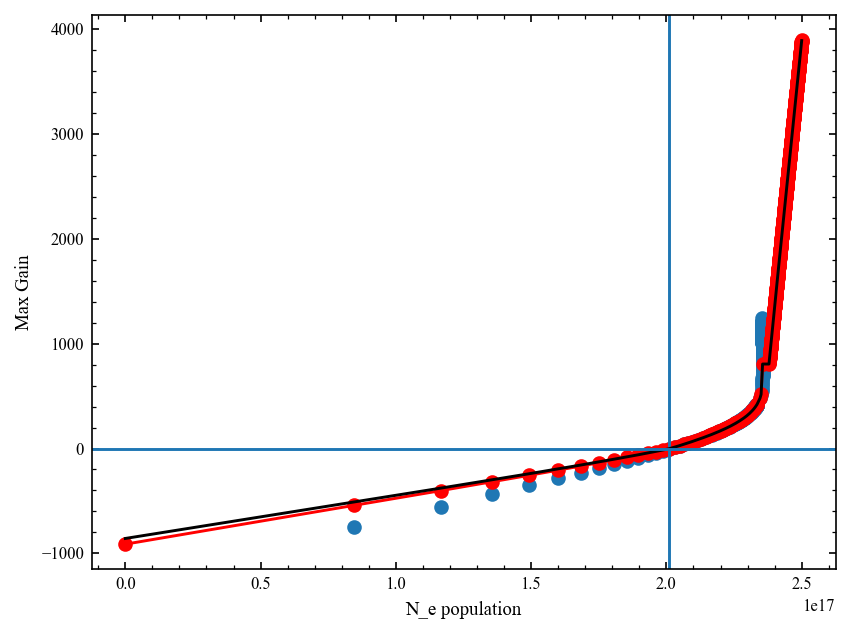

In [61]:
import pandas

index1 = 400
index2 = 500
gamma_xy = 0.08303645356032915
conversion_factor = 4019376.8605
scaling_factor = 1
#plt.scatter(np.sum(N_e_gs, axis=1)[index1:index2],gain_0_arr[35])
plt.scatter(scaling_factor*np.sum(N_e_gs, axis=1)/40e-3,conversion_factor/ gamma_xy*gain_0_arr[:,36])
zero_gain_index = np.argmin(np.absolute(conversion_factor/ gamma_xy*gain_0_arr[:,36]))
plt.axvline(x=scaling_factor*np.sum(N_e_gs, axis=1)[zero_gain_index]/40e-3)

df = pandas.read_csv('gain_peak.csv')
wavelength = df['Xvals']*1E18
raw_gain =  df['Yvals1 ']
fitted_gain = df['Yvals2 ']

plt.scatter(wavelength,raw_gain,color='red')
plt.plot(wavelength,raw_gain,color='red')
plt.plot(wavelength,fitted_gain,color='black')

print(zero_gain_index)
plt.axhline(y=0)
plt.xlabel('N_e population')
plt.ylabel('Max Gain')
plt.show()

2.3545338654262518e+17
4.687900664971024e+17
7.068347570822034e+17


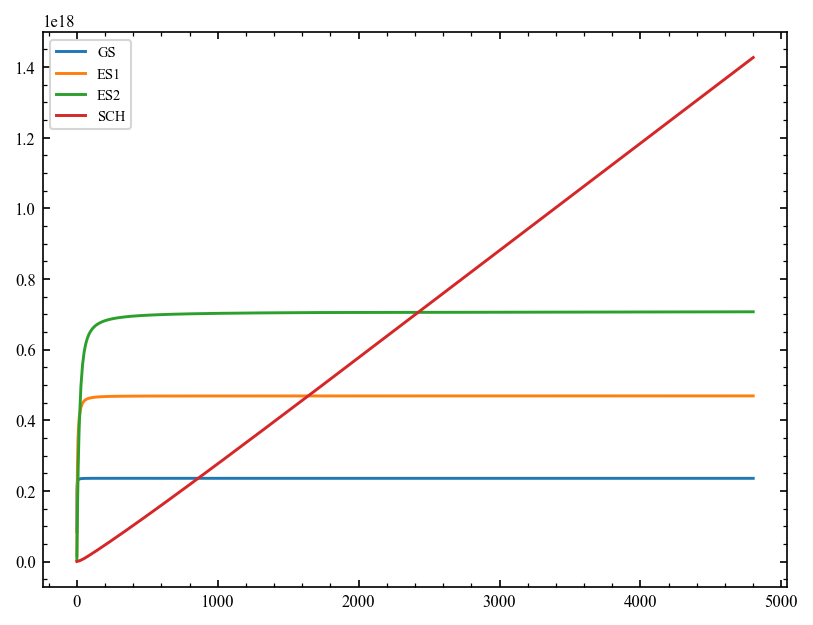

In [50]:
index = 500
plt.plot(J_trimmed[:index]*2.4E-6*400E-6*1E3,np.sum(N_e_gs,axis=1)[:index]/40E-3,label='GS')
plt.plot(J_trimmed[:index]*2.4E-6*400E-6*1E3,np.sum(N_e_es1,axis=1)[:index]/40E-3,label='ES1')
plt.plot(J_trimmed[:index]*2.4E-6*400E-6*1E3,np.sum(N_e_es2,axis=1)[:index]/40E-3,label='ES2')
#plt.plot(J_trimmed[:index]*2.4E-6*400E-6*1E3,N_e_w[:index]/40E-3,label='W')
plt.plot(J_trimmed[:index]*2.4E-6*400E-6*1E3,N_e_sch[:index]/460E-3,label='SCH')

print(np.sum(N_e_gs,axis=1)[-1]/40E-3)
print(np.sum(N_e_es1,axis=1)[-1]/40E-3)
print(np.sum(N_e_es2,axis=1)[-1]/40E-3)

plt.legend()
plt.show()